In [1]:
# MAJOR PROJECT ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.edgecolor"   : "#cccccc",
    "axes.grid"        : True,
    "grid.color"       : "#eeeeee",
    "grid.linewidth"   : 0.6,
    "font.family"      : "sans-serif",
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
})

BASE  = r"C:\Users\User\Desktop\major_project"
CLEAN = os.path.join(BASE, "data_cleaned")
OUT   = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

PALETTE = ["#2563eb","#16a34a","#ea580c","#9333ea","#0891b2","#dc2626"]

print("Libraries loaded")
print(f"Output folder ready: {OUT}")

Libraries loaded
Output folder ready: C:\Users\User\Desktop\major_project\outputs


In [2]:
# Loading all cleaned datasets
sales    = pd.read_excel(os.path.join(CLEAN, "sales_billing_data_cleaned.xlsx"),
                         parse_dates=["Invoice_Date"])
purchase = pd.read_excel(os.path.join(CLEAN, "purchase_data_cleaned.xlsx"),
                         parse_dates=["Invoice_Date"])
orders   = pd.read_excel(os.path.join(CLEAN, "app_order_data_cleaned.xlsx"),
                         parse_dates=["Order Date"])
sku      = pd.read_excel(os.path.join(CLEAN, "sku_master_cleaned.xlsx"))
outlet   = pd.read_excel(os.path.join(CLEAN, "outlet_master_cleaned.xlsx"))
stock    = pd.read_excel(os.path.join(CLEAN, "stock_snapshots_cleaned.xlsx"),
                         parse_dates=["Snapshot_Date"])

# Filter stock — remove sync files
stock = stock[stock["Is_Sync_File"] == False].copy()

print("DATASETS LOADED")
print("="*45)
print(f"Sales      : {len(sales):>6,} rows | {sales['Invoice_Date'].min().date()} → {sales['Invoice_Date'].max().date()}")
print(f"Purchase   : {len(purchase):>6,} rows | {purchase['Invoice_Date'].min().date()} → {purchase['Invoice_Date'].max().date()}")
print(f"Orders     : {len(orders):>6,} rows | {orders['Order Date'].min().date()} → {orders['Order Date'].max().date()}")
print(f"SKU Master : {len(sku):>6,} rows")
print(f"Outlets    : {len(outlet):>6,} rows")
print(f"Stock      : {len(stock):>6,} rows | {stock['Snapshot_Date'].min().date()} → {stock['Snapshot_Date'].max().date()}")

DATASETS LOADED
Sales      : 13,290 rows | 2023-06-29 → 2026-03-31
Purchase   : 10,071 rows | 2023-11-28 → 2026-03-30
Orders     :  2,558 rows | 2025-11-28 → 2026-03-29
SKU Master :  5,363 rows
Outlets    :    107 rows
Stock      : 99,092 rows | 2025-11-10 → 2026-03-31


In [3]:
# Adding Month period column to each dataset
sales["Month"]    = sales["Invoice_Date"].dt.to_period("M")
purchase["Month"] = purchase["Invoice_Date"].dt.to_period("M")
orders["Month"]   = orders["Order Date"].dt.to_period("M")
stock["Month"]    = stock["Snapshot_Date"].dt.to_period("M")

# Adding Financial Year column
def get_fy(dt):
    if dt.month >= 4:
        return f"FY {dt.year}-{str(dt.year+1)[-2:]}"
    return f"FY {dt.year-1}-{str(dt.year)[-2:]}"

sales["FY"]    = sales["Invoice_Date"].apply(get_fy)
purchase["FY"] = purchase["Invoice_Date"].apply(get_fy)

# Separate current firm (K-prefix) from previous firm (M-prefix)
sales_current  = sales[sales["Invoice_Number"].astype(str).str.upper().str.startswith("K")].copy()
sales_previous = sales[sales["Invoice_Number"].astype(str).str.upper().str.startswith("M")].copy()

# Retailer orders only (exclude stock orders)
orders_retail = orders[orders["Order Type"] == "RETAILER"].copy()

print("COLUMNS ADDED")
print("="*45)
print(f"Sales months range    : {sales['Month'].min()} → {sales['Month'].max()}")
print(f"Purchase months range : {purchase['Month'].min()} → {purchase['Month'].max()}")
print(f"Orders months range   : {orders['Month'].min()} → {orders['Month'].max()}")
print(f"\nFY breakdown in sales:")
print(sales["FY"].value_counts().sort_index().to_string())
print(f"\nCurrent firm rows  : {len(sales_current):,}")
print(f"Previous firm rows : {len(sales_previous):,}")
print(f"\nRetailer orders    : {len(orders_retail):,} rows")
print(f"Stock orders       : {len(orders) - len(orders_retail):,} rows")

COLUMNS ADDED
Sales months range    : 2023-06 → 2026-03
Purchase months range : 2023-11 → 2026-03
Orders months range   : 2025-11 → 2026-03

FY breakdown in sales:
FY
FY 2023-24    4177
FY 2024-25    4135
FY 2025-26    4978

Current firm rows  : 11,253
Previous firm rows : 2,037

Retailer orders    : 1,945 rows
Stock orders       : 613 rows


In [4]:
# Key summary numbers for Chapter 4
print("OVERALL BUSINESS SUMMARY")
print("="*45)

print("\n SALES")
print(f"  Total units sold      : {sales['Quantity'].sum():,}")
print(f"  Total sales value     : ₹{sales['Item_Total'].sum():,.0f}")
print(f"  Unique invoices       : {sales['Invoice_Number'].nunique():,}")
print(f"  Unique retailers      : {sales['Party_Code'].nunique()}")
print(f"  Unique SKUs sold      : {sales['SKU_Code'].nunique():,}")
print(f"  Avg qty per invoice   : {sales['Quantity'].sum()/sales['Invoice_Number'].nunique():.1f} units")
print(f"  Avg value per invoice : ₹{sales['Item_Total'].sum()/sales['Invoice_Number'].nunique():,.0f}")

print("\n PURCHASE")
print(f"  Total units purchased : {purchase['Quantity'].sum():,}")
print(f"  Total purchase value  : ₹{purchase['Item_Amount'].sum():,.0f}")
print(f"  Unique invoices       : {purchase['Invoice_Number'].nunique():,}")
print(f"  Unique SKUs purchased : {purchase['SKU_Code'].nunique():,}")

print("\n APP ORDERS (Retailer only)")
print(f"  Total qty ordered     : {orders_retail['Quantity'].sum():,}")
print(f"  Unique orders         : {orders_retail['Order Number'].nunique()}")
print(f"  Unique retailers      : {orders_retail['Party Name'].nunique()}")
print(f"  Unique SKUs ordered   : {orders_retail['SKU_Code'].nunique():,}")

print("\n STOCK")
print(f"  Usable snapshots      : {stock['Snapshot_Date'].nunique()}")
print(f"  Unique SKUs tracked   : {stock['SKU_Code'].nunique():,}")
print(f"  Latest snapshot       : {stock['Snapshot_Date'].max().date()}")

print("\n OUTLETS")
print(f"  Total registered      : {len(outlet)}")
print(f"  Active (Mar 2026)     : {(outlet['Active_Status']=='ACTIVE').sum()}")
print(f"  Inactive              : {(outlet['Active_Status']=='INACTIVE').sum()}")
print(f"  Total beats           : {outlet['Beat'].nunique()}")

OVERALL BUSINESS SUMMARY

 SALES
  Total units sold      : 23,785
  Total sales value     : ₹13,756,791
  Unique invoices       : 468
  Unique retailers      : 46
  Unique SKUs sold      : 2,562
  Avg qty per invoice   : 50.8 units
  Avg value per invoice : ₹29,395

 PURCHASE
  Total units purchased : 23,927
  Total purchase value  : ₹11,975,363
  Unique invoices       : 428
  Unique SKUs purchased : 2,646

 APP ORDERS (Retailer only)
  Total qty ordered     : 3,970
  Unique orders         : 70
  Unique retailers      : 32
  Unique SKUs ordered   : 940

 STOCK
  Usable snapshots      : 123
  Unique SKUs tracked   : 1,338
  Latest snapshot       : 2026-03-31

 OUTLETS
  Total registered      : 107
  Active (Mar 2026)     : 46
  Inactive              : 61
  Total beats           : 13


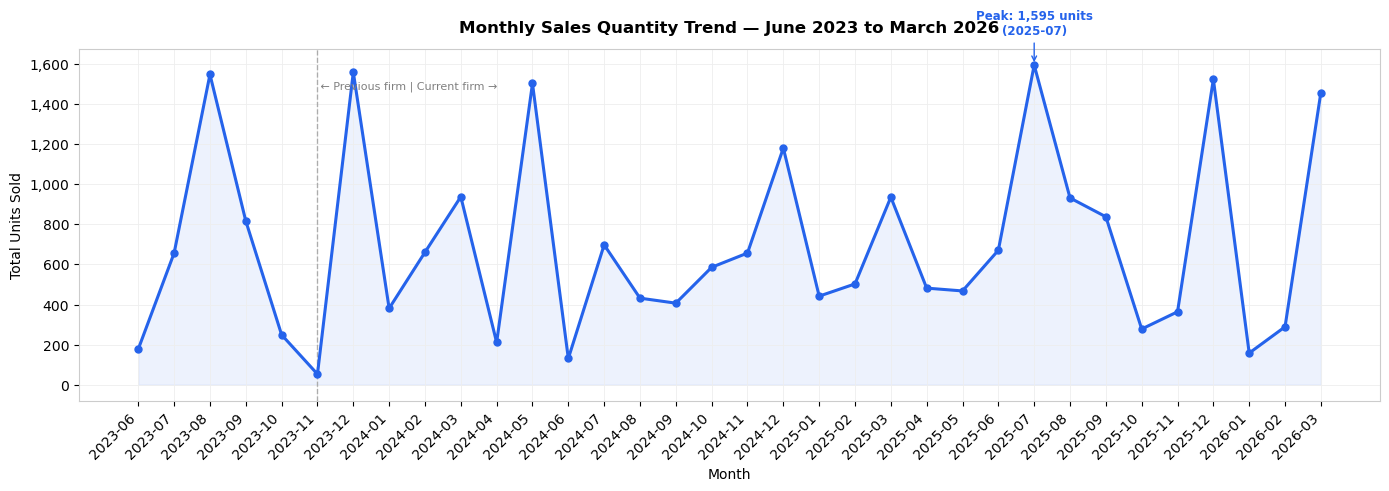

 Chart 1 saved


In [6]:
monthly_sales = (sales.groupby("Month")["Quantity"]
                 .sum().reset_index())
monthly_sales["Month_str"] = monthly_sales["Month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_sales["Month_str"], monthly_sales["Quantity"],
        color=PALETTE[0], marker="o", markersize=5, linewidth=2.2, zorder=3)
ax.fill_between(monthly_sales["Month_str"], monthly_sales["Quantity"],
                alpha=0.08, color=PALETTE[0])

# Annotate peak month
peak_idx = monthly_sales["Quantity"].idxmax()
ax.annotate(
    f"Peak: {monthly_sales.loc[peak_idx,'Quantity']:,} units\n({monthly_sales.loc[peak_idx,'Month_str']})",
    xy=(monthly_sales.loc[peak_idx,"Month_str"], monthly_sales.loc[peak_idx,"Quantity"]),
    xytext=(0, 22), textcoords="offset points",
    ha="center", fontsize=8.5, color=PALETTE[0], fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=PALETTE[0], lw=1)
)

# Adding vertical line separating firms
split_x = "2023-11"
ax.axvline(x=split_x, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.text("2023-11", monthly_sales["Quantity"].max() * 0.95,
        " ← Previous firm | Current firm →",
        fontsize=8, color="gray", va="top")

ax.set_title("Monthly Sales Quantity Trend — June 2023 to March 2026", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Total Units Sold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_01_monthly_sales_trend.png"), dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 1 saved")

FY-WISE SUMMARY

  FY 2023-24
    Units sold  : 7,041
    Sales value : ₹4,076,667 (₹40.77L)
    Invoices    : 158
    Unique SKUs : 1,565

  FY 2024-25
    Units sold  : 7,687
    Sales value : ₹4,240,821 (₹42.41L)
    Invoices    : 298
    Unique SKUs : 1,259

  FY 2025-26
    Units sold  : 9,057
    Sales value : ₹5,439,302 (₹54.39L)
    Invoices    : 342
    Unique SKUs : 1,383

  YoY Growth (FY 2024-25 → FY 2025-26)
    Quantity growth : +17.8%
    Value growth    : +28.3%


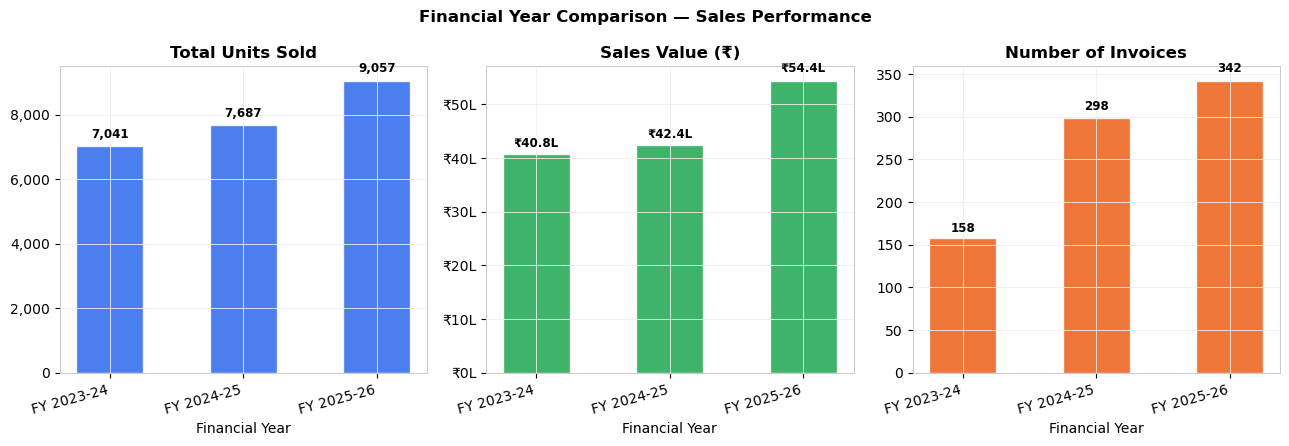

 Chart 2 saved


In [7]:
fy_summary = (sales.groupby("FY")
              .agg(
                  Qty      = ("Quantity",       "sum"),
                  Value    = ("Item_Total",      "sum"),
                  Invoices = ("Invoice_Number",  "nunique"),
                  SKUs     = ("SKU_Code",        "nunique")
              ).reset_index().sort_values("FY"))

print("FY-WISE SUMMARY")
print("="*55)
for _, row in fy_summary.iterrows():
    print(f"\n  {row['FY']}")
    print(f"    Units sold  : {row['Qty']:,}")
    print(f"    Sales value : ₹{row['Value']:,.0f} (₹{row['Value']/1e5:.2f}L)")
    print(f"    Invoices    : {row['Invoices']}")
    print(f"    Unique SKUs : {row['SKUs']:,}")

# Growth calculation
fy_list = fy_summary["FY"].tolist()
if len(fy_list) >= 2:
    growth_qty = ((fy_summary.iloc[-1]["Qty"] - fy_summary.iloc[-2]["Qty"])
                  / fy_summary.iloc[-2]["Qty"] * 100)
    growth_val = ((fy_summary.iloc[-1]["Value"] - fy_summary.iloc[-2]["Value"])
                  / fy_summary.iloc[-2]["Value"] * 100)
    print(f"\n  YoY Growth ({fy_list[-2]} → {fy_list[-1]})")
    print(f"    Quantity growth : {growth_qty:+.1f}%")
    print(f"    Value growth    : {growth_val:+.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

metrics = [
    ("Qty",      "Total Units Sold",     PALETTE[0]),
    ("Value",    "Sales Value (₹)",      PALETTE[1]),
    ("Invoices", "Number of Invoices",   PALETTE[2]),
]

for ax, (col, label, color) in zip(axes, metrics):
    bars = ax.bar(fy_summary["FY"], fy_summary[col],
                  color=color, alpha=0.82, edgecolor="white", width=0.5)
    for bar in bars:
        h = bar.get_height()
        txt = f"₹{h/1e5:.1f}L" if col == "Value" else f"{int(h):,}"
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.02,
                txt, ha="center", va="bottom", fontsize=8.5, fontweight="bold")
    ax.set_title(label)
    ax.set_xlabel("Financial Year")
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
    if col == "Value":
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"₹{x/1e5:.0f}L"))
    else:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Financial Year Comparison — Sales Performance", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_02_fy_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 2 saved")

TOP 20 SKUs BY SALES QUANTITY
Rank   SKU Code                            Qty % of Total
---------------------------------------------
1      NR57_MCD_M                          152       0.6%
2      NR57_MCP_M                          143       0.6%
3      D104_SKIN_34B                       135       0.6%
4      D104_BLACK_38C                      131       0.6%
5      D104_SKIN_38C                       130       0.5%
6      NR57_MCD_L                          130       0.5%
7      D104_BLACK_34B                      129       0.5%
8      NR57_MCP_L                          128       0.5%
9      D104_BLACK_36C                      127       0.5%
10     D104_SKIN_36B                       127       0.5%
11     D104_BLACK_36B                      121       0.5%
12     D104_SKIN_36C                       119       0.5%
13     TB17_SKIN_M                         119       0.5%
14     D104_BLACK_34C                      112       0.5%
15     TB17_BLACK_M                        111       0

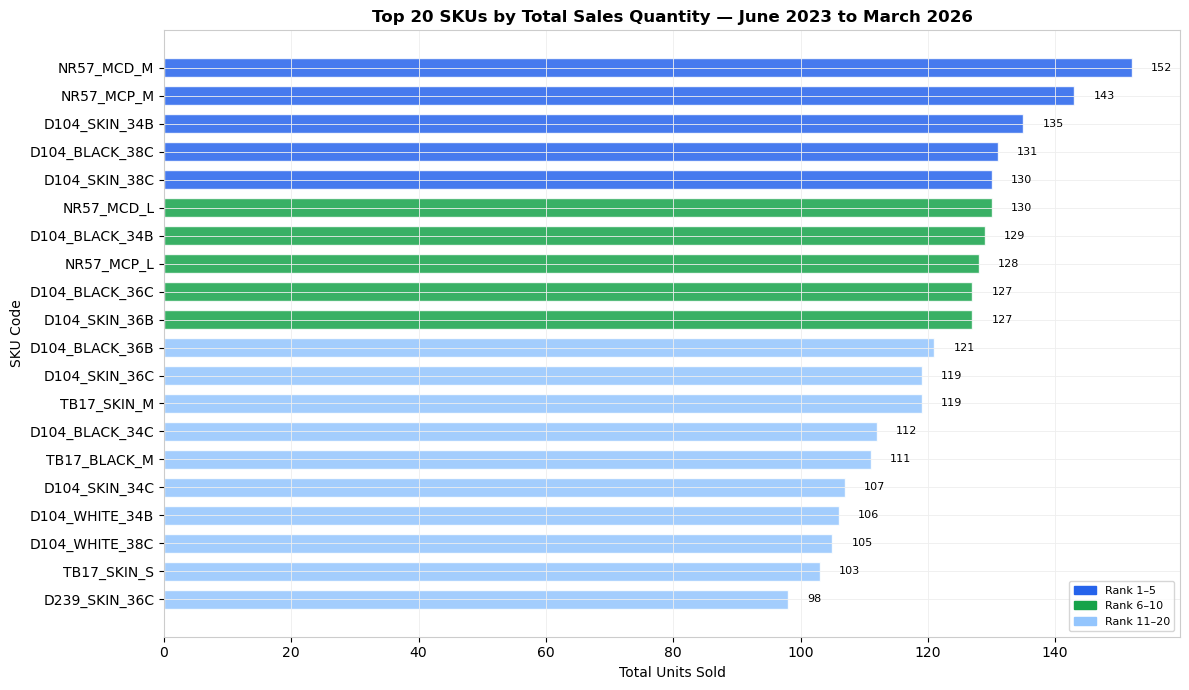

 Chart 3 saved


In [8]:
top_skus = (sales.groupby("SKU_Code")["Quantity"]
            .sum()
            .sort_values(ascending=False)
            .head(20)
            .reset_index())

top_skus.columns = ["SKU_Code", "Total_Qty"]
top_skus["Rank"] = range(1, 21)

print("TOP 20 SKUs BY SALES QUANTITY")
print("="*45)
print(f"{'Rank':<6} {'SKU Code':<30} {'Qty':>8} {'% of Total':>10}")
print("-"*45)
total = sales["Quantity"].sum()
for _, row in top_skus.iterrows():
    pct = row["Total_Qty"] / total * 100
    print(f"{int(row['Rank']):<6} {row['SKU_Code']:<30} {int(row['Total_Qty']):>8,} {pct:>9.1f}%")

top20_pct = top_skus["Total_Qty"].sum() / total * 100
print(f"\n  Top 20 SKUs account for {top20_pct:.1f}% of total sales volume")

fig, ax = plt.subplots(figsize=(12, 7))
colors = [PALETTE[0] if i < 5 else PALETTE[1] if i < 10 else "#93c5fd"
          for i in range(20)]
bars = ax.barh(top_skus["SKU_Code"][::-1], top_skus["Total_Qty"][::-1],
               color=colors[::-1], alpha=0.85, edgecolor="white", height=0.7)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 3, bar.get_y() + bar.get_height()/2,
            f"{int(w):,}", va="center", fontsize=8)

ax.set_title("Top 20 SKUs by Total Sales Quantity — June 2023 to March 2026")
ax.set_xlabel("Total Units Sold")
ax.set_ylabel("SKU Code")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

from matplotlib.patches import Patch
legend = [Patch(color=PALETTE[0], label="Rank 1–5"),
          Patch(color=PALETTE[1], label="Rank 6–10"),
          Patch(color="#93c5fd",  label="Rank 11–20")]
ax.legend(handles=legend, loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_03_top20_skus.png"), dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 3 saved")

TOP 10 STYLES BY SALES QUANTITY
Rank   Style             Qty  % Share
----------------------------------------
1      D104            6,280    26.4%
2      D239            4,280    18.0%
3      TB17            2,049     8.6%
4      NR57            1,283     5.4%
5      H162            1,031     4.3%
6      D368              517     2.2%
7      D374              467     2.0%
8      NR48              460     1.9%
9      NR86              407     1.7%
10     D271              343     1.4%

  Top 10 styles = 72.0% of total sales volume


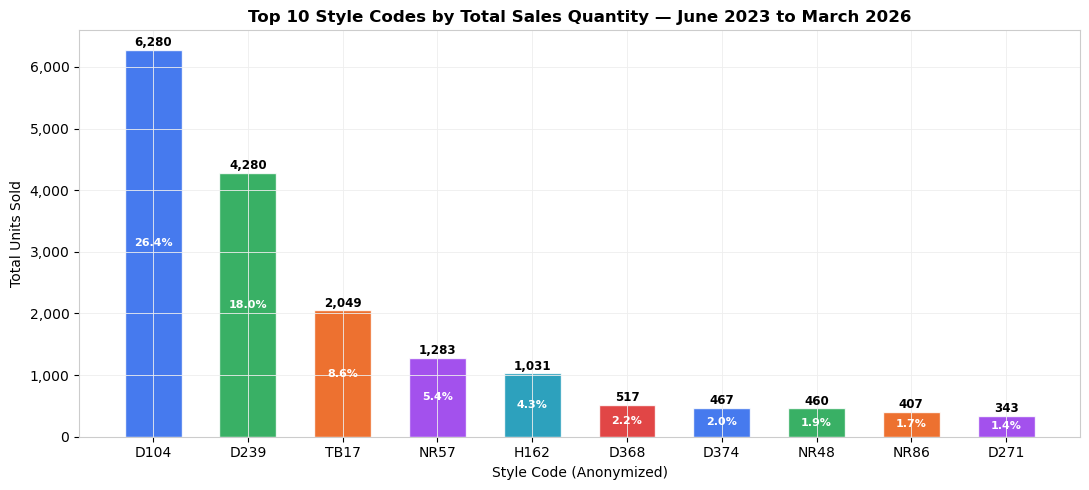

 Chart 4 saved


In [9]:
top_styles = (sales.groupby("Style")["Quantity"]
              .sum()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())
top_styles.columns = ["Style", "Total_Qty"]
top_styles["Pct"] = (top_styles["Total_Qty"] / sales["Quantity"].sum() * 100).round(1)

print("TOP 10 STYLES BY SALES QUANTITY")
print("="*40)
print(f"{'Rank':<6} {'Style':<12} {'Qty':>8} {'% Share':>8}")
print("-"*40)
for i, row in top_styles.iterrows():
    print(f"{i+1:<6} {row['Style']:<12} {int(row['Total_Qty']):>8,} {row['Pct']:>7.1f}%")

top10_pct = top_styles["Total_Qty"].sum() / sales["Quantity"].sum() * 100
print(f"\n  Top 10 styles = {top10_pct:.1f}% of total sales volume")

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(top_styles["Style"], top_styles["Total_Qty"],
              color=PALETTE[:len(top_styles)], alpha=0.85,
              edgecolor="white", width=0.6)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 10,
            f"{int(h):,}", ha="center", va="bottom",
            fontsize=8.5, fontweight="bold")

# Adding percentage labels inside bars
for bar, (_, row) in zip(bars, top_styles.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() / 2,
            f"{row['Pct']}%", ha="center", va="center",
            fontsize=8, color="white", fontweight="bold")

ax.set_title("Top 10 Style Codes by Total Sales Quantity — June 2023 to March 2026")
ax.set_xlabel("Style Code (Anonymized)")
ax.set_ylabel("Total Units Sold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_04_top10_styles.png"), dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 4 saved")

SALES BY CATEGORY
Category               Qty    Qty%   Value(₹L)   Val%
------------------------------------------------------------
UNCATEGORIZED       23,484   98.7%   ₹ 135.06L  98.2%
FASHION                166    0.7%   ₹   1.64L   1.2%
SS26                   135    0.6%   ₹   0.87L   0.6%


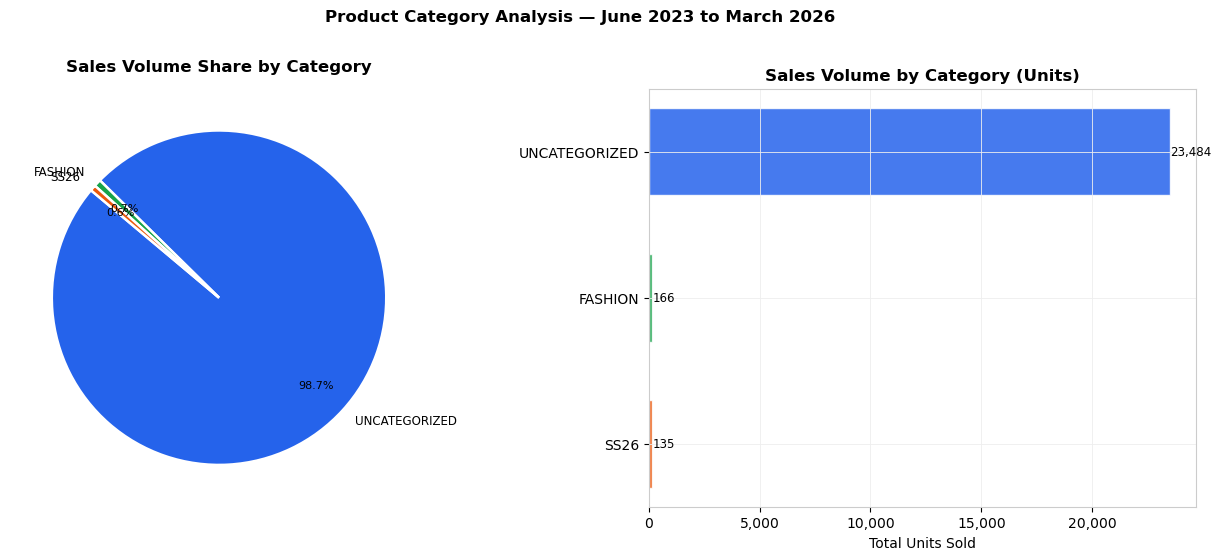

 Chart 5 saved


In [10]:
# Join category from SKU master
sku_cat = sku[["Style","Category"]].drop_duplicates(subset="Style", keep="first")
sales_cat = sales.merge(sku_cat, on="Style", how="left")
sales_cat["Category"] = sales_cat["Category"].fillna("UNCATEGORIZED")

cat_summary = (sales_cat.groupby("Category")
               .agg(Qty=("Quantity","sum"), Value=("Item_Total","sum"))
               .reset_index()
               .sort_values("Qty", ascending=False))
cat_summary["Qty_Pct"]   = (cat_summary["Qty"]   / cat_summary["Qty"].sum()   * 100).round(1)
cat_summary["Value_Pct"] = (cat_summary["Value"] / cat_summary["Value"].sum() * 100).round(1)

print("SALES BY CATEGORY")
print("="*60)
print(f"{'Category':<18} {'Qty':>7} {'Qty%':>7} {'Value(₹L)':>11} {'Val%':>6}")
print("-"*60)
for _, row in cat_summary.iterrows():
    print(f"{row['Category']:<18} {int(row['Qty']):>7,} {row['Qty_Pct']:>6.1f}% "
          f"  ₹{row['Value']/1e5:>7.2f}L {row['Value_Pct']:>5.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

colors_cat = PALETTE[:len(cat_summary)]

# Pie chart
wedges, texts, autotexts = ax1.pie(
    cat_summary["Qty"],
    labels=cat_summary["Category"],
    autopct="%1.1f%%",
    colors=colors_cat,
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor="white", linewidth=1.8)
)
for at in autotexts:
    at.set_fontsize(8)
for t in texts:
    t.set_fontsize(8.5)
ax1.set_title("Sales Volume Share by Category", pad=12)

# Horizontal bar
bars = ax2.barh(cat_summary["Category"][::-1],
                cat_summary["Qty"][::-1],
                color=colors_cat[::-1], alpha=0.85,
                edgecolor="white", height=0.6)
for bar in bars:
    w = bar.get_width()
    ax2.text(w + 30, bar.get_y() + bar.get_height()/2,
             f"{int(w):,}", va="center", fontsize=8.5)
ax2.set_title("Sales Volume by Category (Units)")
ax2.set_xlabel("Total Units Sold")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Product Category Analysis — June 2023 to March 2026",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_05_category_breakdown.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 5 saved")

Style-Category pairs from purchase data: 107

SALES BY CATEGORY
Category               Qty    Qty%   Value(₹L)   Val%
------------------------------------------------------------
OTHER               19,043   80.1%  ₹ 111.50L  81.1%
CORE                 4,280   18.0%  ₹  23.40L  17.0%
NCP-P010               310    1.3%  ₹   1.49L   1.1%
SS26                   146    0.6%  ₹   1.11L   0.8%
FASHION                  6    0.0%  ₹   0.06L   0.0%


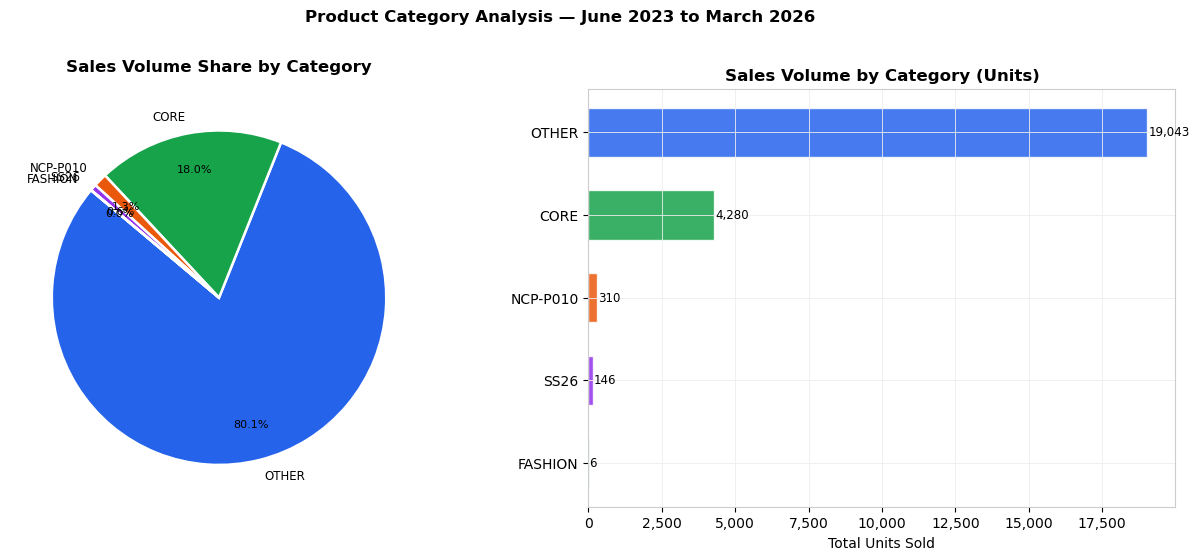

 Chart 5 saved


In [11]:
# Build Style → Category lookup from purchase data
# (purchase already has Category correctly mapped from clean_06e)
style_cat_lookup = (purchase[purchase["Category"].notna()]
                    [["Style","Category"]]
                    .drop_duplicates(subset="Style", keep="first"))

print(f"Style-Category pairs from purchase data: {len(style_cat_lookup)}")

# Join to sales
sales_cat = sales.merge(style_cat_lookup, on="Style", how="left")
sales_cat["Category"] = sales_cat["Category"].fillna("OTHER")

cat_summary = (sales_cat.groupby("Category")
               .agg(Qty=("Quantity","sum"), Value=("Item_Total","sum"))
               .reset_index()
               .sort_values("Qty", ascending=False))
cat_summary["Qty_Pct"]   = (cat_summary["Qty"]   / cat_summary["Qty"].sum()   * 100).round(1)
cat_summary["Value_Pct"] = (cat_summary["Value"] / cat_summary["Value"].sum() * 100).round(1)

print("\nSALES BY CATEGORY")
print("="*60)
print(f"{'Category':<18} {'Qty':>7} {'Qty%':>7} {'Value(₹L)':>11} {'Val%':>6}")
print("-"*60)
for _, row in cat_summary.iterrows():
    print(f"{row['Category']:<18} {int(row['Qty']):>7,} {row['Qty_Pct']:>6.1f}%"
          f"  ₹{row['Value']/1e5:>7.2f}L {row['Value_Pct']:>5.1f}%")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
colors_cat = PALETTE[:len(cat_summary)]

wedges, texts, autotexts = ax1.pie(
    cat_summary["Qty"], labels=cat_summary["Category"],
    autopct="%1.1f%%", colors=colors_cat,
    startangle=140, pctdistance=0.78,
    wedgeprops=dict(edgecolor="white", linewidth=1.8))
for at in autotexts: at.set_fontsize(8)
for t in texts: t.set_fontsize(8.5)
ax1.set_title("Sales Volume Share by Category", pad=12)

bars = ax2.barh(cat_summary["Category"][::-1],
                cat_summary["Qty"][::-1],
                color=colors_cat[::-1], alpha=0.85,
                edgecolor="white", height=0.6)
for bar in bars:
    w = bar.get_width()
    ax2.text(w + 30, bar.get_y() + bar.get_height()/2,
             f"{int(w):,}", va="center", fontsize=8.5)
ax2.set_title("Sales Volume by Category (Units)")
ax2.set_xlabel("Total Units Sold")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Product Category Analysis — June 2023 to March 2026",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_05_category_breakdown.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 5 saved")

In [12]:
# Trying joining via SKU_Code (Style_Color_Size) from SKU master
sku_lookup = (sku[["SKU_Code","Category"]]
              .drop_duplicates(subset="SKU_Code", keep="first"))

# Also get from purchase data as backup
purchase_lookup = (purchase[purchase["Category"].notna()]
                   [["SKU_Code","Category"]]
                   .drop_duplicates(subset="SKU_Code", keep="first"))

# Combine both lookups
combined_lookup = pd.concat([sku_lookup, purchase_lookup]).drop_duplicates(
    subset="SKU_Code", keep="first")

print(f"SKU master entries       : {len(sku_lookup)}")
print(f"Purchase lookup entries  : {len(purchase_lookup)}")
print(f"Combined lookup entries  : {len(combined_lookup)}")

# Checking overlap with sales
sales_skus = set(sales["SKU_Code"].unique())
lookup_skus = set(combined_lookup["SKU_Code"].unique())
overlap = sales_skus & lookup_skus
print(f"\nSales unique SKU_Codes   : {len(sales_skus)}")
print(f"Matched in combined lookup: {len(overlap)}")
print(f"Match rate               : {len(overlap)/len(sales_skus)*100:.1f}%")

# Sample of unmatched
unmatched_skus = sales_skus - lookup_skus
print(f"\nSample unmatched sales SKUs:")
for s in list(unmatched_skus)[:10]:
    print(f"  {s}")

SKU master entries       : 5353
Purchase lookup entries  : 2440
Combined lookup entries  : 6713

Sales unique SKU_Codes   : 2563
Matched in combined lookup: 30
Match rate               : 1.2%

Sample unmatched sales SKUs:
  D271_BLACK_38B
  D104_RESWPR_36D
  D907_CMG_40Z
  D104_RESWPR_34C
  HB70_ECL_42C
  DB88_PLS_34C
  H781_ROSSKN_38D
  D239_SKIN_40C
  DB88_PEARL_36C
  TB93_BLACK_34C


Category lookup pairs: 107

SALES BY CATEGORY
Category               Qty    Qty%   Value(₹L)   Val%
------------------------------------------------------------
CORE                16,827   70.7%  ₹  91.99L  66.9%
FASHION              2,388   10.0%  ₹  23.57L  17.1%
NCP-P010             1,936    8.1%  ₹   8.88L   6.5%
OTHER                1,613    6.8%  ₹   8.03L   5.8%
SS26                   599    2.5%  ₹   3.75L   2.7%
NCP                    218    0.9%  ₹   0.60L   0.4%
NCP-P05                204    0.9%  ₹   0.76L   0.6%


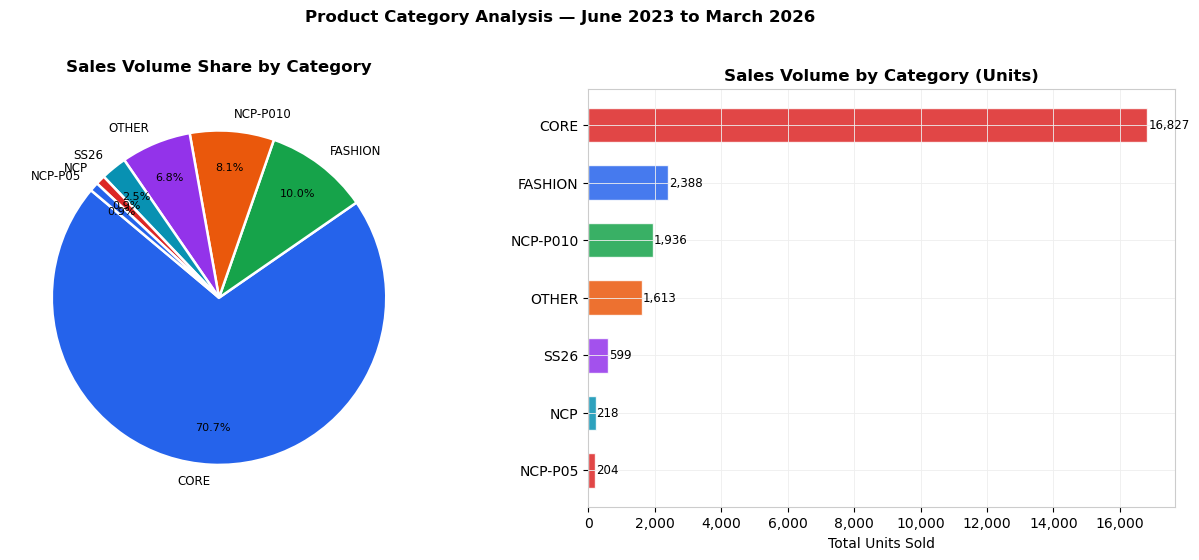

 Chart 5 saved


In [6]:
# Build category lookup from purchase data (now aligned with sales)
cat_lookup = (purchase[purchase["Category"].notna()]
              [["Style", "Category"]]
              .drop_duplicates(subset="Style", keep="first"))

print(f"Category lookup pairs: {len(cat_lookup)}")

# Join to sales on Style
sales_cat = sales.merge(cat_lookup, on="Style", how="left")
sales_cat["Category"] = sales_cat["Category"].fillna("OTHER")

cat_summary = (sales_cat.groupby("Category")
               .agg(Qty=("Quantity","sum"), Value=("Item_Total","sum"))
               .reset_index()
               .sort_values("Qty", ascending=False))
cat_summary["Qty_Pct"]   = (cat_summary["Qty"] / cat_summary["Qty"].sum() * 100).round(1)
cat_summary["Value_Pct"] = (cat_summary["Value"] / cat_summary["Value"].sum() * 100).round(1)

print("\nSALES BY CATEGORY")
print("="*60)
print(f"{'Category':<18} {'Qty':>7} {'Qty%':>7} {'Value(₹L)':>11} {'Val%':>6}")
print("-"*60)
for _, row in cat_summary.iterrows():
    print(f"{row['Category']:<18} {int(row['Qty']):>7,} {row['Qty_Pct']:>6.1f}%"
          f"  ₹{row['Value']/1e5:>7.2f}L {row['Value_Pct']:>5.1f}%")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
colors_cat = PALETTE[:len(cat_summary)]

wedges, texts, autotexts = ax1.pie(
    cat_summary["Qty"], labels=cat_summary["Category"],
    autopct="%1.1f%%", colors=colors_cat,
    startangle=140, pctdistance=0.78,
    wedgeprops=dict(edgecolor="white", linewidth=1.8))
for at in autotexts: at.set_fontsize(8)
for t in texts: t.set_fontsize(8.5)
ax1.set_title("Sales Volume Share by Category", pad=12)

bars = ax2.barh(cat_summary["Category"][::-1],
                cat_summary["Qty"][::-1],
                color=colors_cat[::-1], alpha=0.85,
                edgecolor="white", height=0.6)
for bar in bars:
    w = bar.get_width()
    ax2.text(w + 30, bar.get_y() + bar.get_height()/2,
             f"{int(w):,}", va="center", fontsize=8.5)
ax2.set_title("Sales Volume by Category (Units)")
ax2.set_xlabel("Total Units Sold")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Product Category Analysis — June 2023 to March 2026",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_05_category_breakdown.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 5 saved")

TOP 15 RETAILERS BY SALES QUANTITY
Rank   Retailer               Qty      %  Value(₹L) Invoices
------------------------------------------------------------
1      RETAILER_026         9,056  38.1% ₹  56.38L      150
2      RETAILER_021         3,933  16.5% ₹  21.92L       42
3      RETAILER_006         1,055   4.4% ₹   6.19L       31
4      ERP_ONLY_003           938   3.9% ₹   4.30L       25
5      RETAILER_020           910   3.8% ₹   5.31L       50
6      RETAILER_012           731   3.1% ₹   4.11L       24
7      RETAILER_010           713   3.0% ₹   3.43L       48
8      RETAILER_016           647   2.7% ₹   3.24L       28
9      ERP_ONLY_006           499   2.1% ₹   3.49L       24
10     ERP_ONLY_008           499   2.1% ₹   3.10L       15
11     RETAILER_007           452   1.9% ₹   2.68L       17
12     RETAILER_015           441   1.9% ₹   2.13L       34
13     ERP_ONLY_010           440   1.8% ₹   2.19L       15
14     RETAILER_005           427   1.8% ₹   2.28L       31
15 

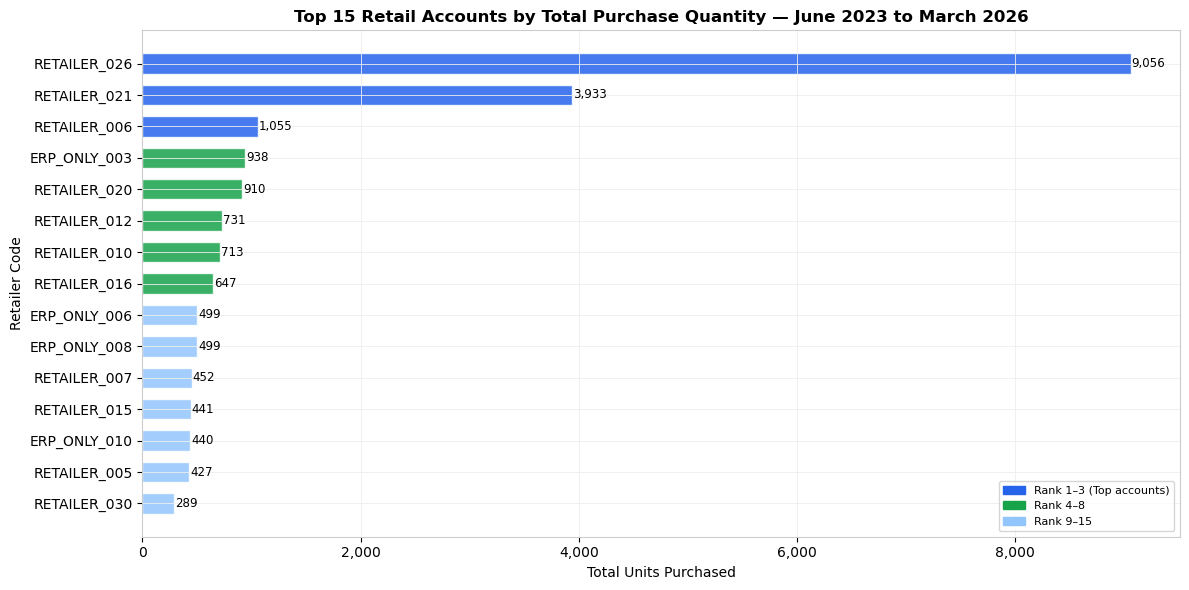

 Chart 6 saved


In [7]:
retailer_summary = (sales.groupby("Party_Code")
                    .agg(
                        Qty      = ("Quantity",       "sum"),
                        Value    = ("Item_Total",     "sum"),
                        Invoices = ("Invoice_Number", "nunique")
                    )
                    .sort_values("Qty", ascending=False)
                    .head(15)
                    .reset_index())

retailer_summary["Value_L"] = retailer_summary["Value"] / 1e5
retailer_summary["Pct"]     = (retailer_summary["Qty"] /
                                sales["Quantity"].sum() * 100).round(1)

print("TOP 15 RETAILERS BY SALES QUANTITY")
print("="*60)
print(f"{'Rank':<6} {'Retailer':<18} {'Qty':>7} {'%':>6} {'Value(₹L)':>10} {'Invoices':>8}")
print("-"*60)
for i, row in retailer_summary.iterrows():
    print(f"{i+1:<6} {row['Party_Code']:<18} {int(row['Qty']):>7,} "
          f"{row['Pct']:>5.1f}% ₹{row['Value_L']:>7.2f}L {int(row['Invoices']):>8}")

top15_pct = retailer_summary["Qty"].sum() / sales["Quantity"].sum() * 100
print(f"\n  Top 15 retailers = {top15_pct:.1f}% of total sales volume")

fig, ax = plt.subplots(figsize=(12, 6))
colors_ret = [PALETTE[0] if i < 3 else PALETTE[1] if i < 8 else "#93c5fd"
              for i in range(len(retailer_summary))]
bars = ax.barh(retailer_summary["Party_Code"][::-1],
               retailer_summary["Qty"][::-1],
               color=colors_ret[::-1], alpha=0.85,
               edgecolor="white", height=0.65)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 10, bar.get_y() + bar.get_height()/2,
            f"{int(w):,}", va="center", fontsize=8.5)

ax.set_title("Top 15 Retail Accounts by Total Purchase Quantity — June 2023 to March 2026")
ax.set_xlabel("Total Units Purchased")
ax.set_ylabel("Retailer Code")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

from matplotlib.patches import Patch
legend = [Patch(color=PALETTE[0], label="Rank 1–3 (Top accounts)"),
          Patch(color=PALETTE[1], label="Rank 4–8"),
          Patch(color="#93c5fd",  label="Rank 9–15")]
ax.legend(handles=legend, loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_06_top15_retailers.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 6 saved")

MONTHLY SALES — CURRENT FIRM (Nov 2023 – Mar 2026)
Month             Qty    Value(₹L)   Invoices
-------------------------------------------------------
2023-11            41   ₹   0.27L          3
2023-12         1,559   ₹  10.22L         23
2024-01           381   ₹   2.29L         17
2024-02           661   ₹   3.73L         20
2024-03           938   ₹   5.88L         17
2024-04           211   ₹   1.17L         17
2024-05         1,503   ₹   7.57L         29
2024-06           131   ₹   0.62L          8
2024-07           698   ₹   3.68L         12
2024-08           432   ₹   2.00L         13
2024-09           407   ₹   2.77L         21
2024-10           586   ₹   3.31L         20
2024-11           657   ₹   3.93L         32
2024-12         1,181   ₹   6.51L         62
2025-01           442   ₹   2.66L         31
2025-02           503   ₹   3.20L         22
2025-03           936   ₹   4.98L         31
2025-04           482   ₹   3.21L         23
2025-05           468   ₹   2.55L    

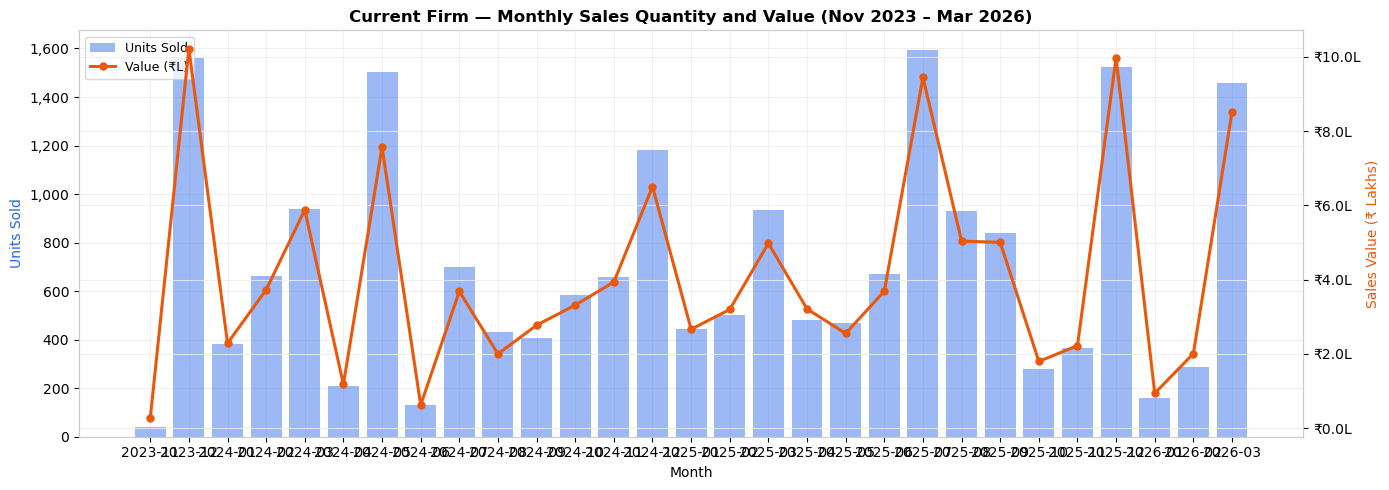

 Chart 7 saved


In [8]:
curr_monthly = (sales_current.groupby("Month")
                .agg(Qty=("Quantity","sum"), Value=("Item_Total","sum"))
                .reset_index())
curr_monthly["Month_str"] = curr_monthly["Month"].astype(str)

print("MONTHLY SALES — CURRENT FIRM (Nov 2023 – Mar 2026)")
print("="*55)
print(f"{'Month':<12} {'Qty':>8} {'Value(₹L)':>12} {'Invoices':>10}")
print("-"*55)

curr_invoices = (sales_current.groupby("Month")["Invoice_Number"]
                 .nunique().reset_index())
curr_invoices["Month_str"] = curr_invoices["Month"].astype(str)
curr_monthly = curr_monthly.merge(curr_invoices[["Month","Invoice_Number"]], on="Month")
curr_monthly.rename(columns={"Invoice_Number":"Invoices"}, inplace=True)

for _, row in curr_monthly.iterrows():
    print(f"{row['Month_str']:<12} {int(row['Qty']):>8,} "
          f"  ₹{row['Value']/1e5:>7.2f}L {int(row['Invoices']):>10}")

print(f"\n  Avg monthly qty   : {curr_monthly['Qty'].mean():.0f} units")
print(f"  Avg monthly value : ₹{curr_monthly['Value'].mean()/1e5:.2f}L")
print(f"  Peak month qty    : {curr_monthly['Qty'].max():,} ({curr_monthly.loc[curr_monthly['Qty'].idxmax(),'Month_str']})")
print(f"  Low month qty     : {curr_monthly['Qty'].min():,} ({curr_monthly.loc[curr_monthly['Qty'].idxmin(),'Month_str']})")

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(curr_monthly["Month_str"], curr_monthly["Qty"],
        color=PALETTE[0], alpha=0.45, label="Units Sold", zorder=2)
ax2.plot(curr_monthly["Month_str"], curr_monthly["Value"]/1e5,
         color=PALETTE[2], marker="o", markersize=5,
         linewidth=2.2, label="Value (₹L)", zorder=3)

ax1.set_title("Current Firm — Monthly Sales Quantity and Value (Nov 2023 – Mar 2026)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Units Sold", color=PALETTE[0])
ax2.set_ylabel("Sales Value (₹ Lakhs)", color=PALETTE[2])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:.1f}L"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left", fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_07_current_firm_monthly.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 7 saved")

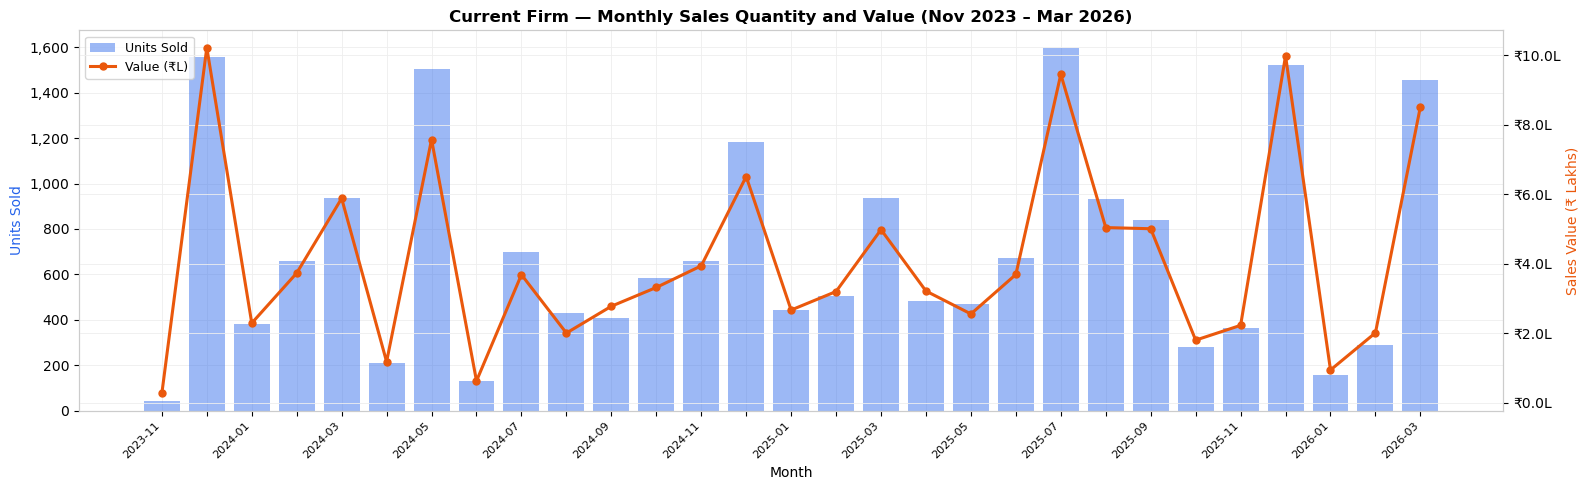

Chart 7 saved


In [9]:
curr_monthly = (sales_current.groupby("Month")
                .agg(Qty=("Quantity","sum"), Value=("Item_Total","sum"))
                .reset_index())
curr_monthly["Month_str"] = curr_monthly["Month"].astype(str)

curr_invoices = (sales_current.groupby("Month")["Invoice_Number"]
                 .nunique().reset_index())
curr_monthly = curr_monthly.merge(curr_invoices, on="Month")
curr_monthly.rename(columns={"Invoice_Number":"Invoices"}, inplace=True)

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

x = range(len(curr_monthly))
ax1.bar(x, curr_monthly["Qty"],
        color=PALETTE[0], alpha=0.45, label="Units Sold", zorder=2)
ax2.plot(x, curr_monthly["Value"]/1e5,
         color=PALETTE[2], marker="o", markersize=5,
         linewidth=2.2, label="Value (₹L)", zorder=3)

# Fix x-axis — show every other label to avoid overlap
ax1.set_xticks(list(x))
ax1.set_xticklabels(
    [m if i % 2 == 0 else "" for i, m in enumerate(curr_monthly["Month_str"])],
    rotation=45, ha="right", fontsize=8
)

ax1.set_title("Current Firm — Monthly Sales Quantity and Value (Nov 2023 – Mar 2026)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Units Sold", color=PALETTE[0])
ax2.set_ylabel("Sales Value (₹ Lakhs)", color=PALETTE[2])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:.1f}L"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_07_current_firm_monthly.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 7 saved")

MONTHLY PURCHASE vs SALES COMPARISON
Month         Purchased     Sold     Diff       Status
-----------------------------------------------------------------
2023-11           2,398       41   +2,357    OVERSTOCK
2023-12           1,067    1,559     -492   UNDERSTOCK
2024-01             775      381     +394    OVERSTOCK
2024-02             618      661      -43     BALANCED
2024-03           1,004      938      +66     BALANCED
2024-04             156      211      -55     BALANCED
2024-05           1,531    1,503      +28     BALANCED
2024-06             135      131       +4     BALANCED
2024-07           1,164      698     +466    OVERSTOCK
2024-08             177      432     -255   UNDERSTOCK
2024-09             379      407      -28     BALANCED
2024-10             627      586      +41     BALANCED
2024-11             775      657     +118    OVERSTOCK
2024-12           1,290    1,181     +109    OVERSTOCK
2025-01             401      442      -41     BALANCED
2025-02          

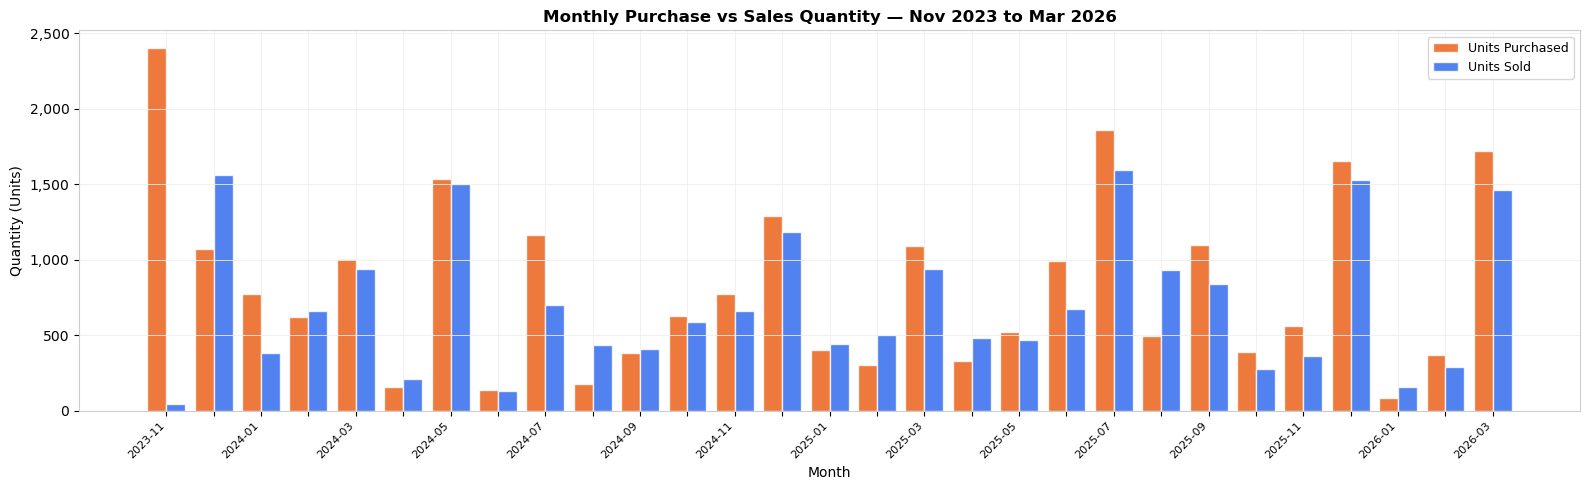

Chart 8 saved


In [10]:
# Monthly purchase vs sales — current firm period only (Nov 2023 onward)
sales_monthly = (sales_current.groupby("Month")["Quantity"]
                 .sum().reset_index().rename(columns={"Quantity":"Sales_Qty"}))

purchase_monthly = (purchase.groupby("Month")["Quantity"]
                    .sum().reset_index().rename(columns={"Quantity":"Purchase_Qty"}))

comparison = pd.merge(sales_monthly, purchase_monthly, on="Month", how="outer").fillna(0)
comparison = comparison.sort_values("Month").reset_index(drop=True)
comparison["Month_str"] = comparison["Month"].astype(str)
comparison["Diff"]      = comparison["Purchase_Qty"] - comparison["Sales_Qty"]

print("MONTHLY PURCHASE vs SALES COMPARISON")
print("="*65)
print(f"{'Month':<12} {'Purchased':>10} {'Sold':>8} {'Diff':>8} {'Status':>12}")
print("-"*65)
for _, row in comparison.iterrows():
    status = "OVERSTOCK" if row["Diff"] > 100 else "UNDERSTOCK" if row["Diff"] < -100 else "BALANCED"
    print(f"{row['Month_str']:<12} {int(row['Purchase_Qty']):>10,} "
          f"{int(row['Sales_Qty']):>8,} {int(row['Diff']):>+8,} {status:>12}")

total_purchased = comparison["Purchase_Qty"].sum()
total_sold      = comparison["Sales_Qty"].sum()
print(f"\n  Total purchased : {total_purchased:,.0f} units")
print(f"  Total sold      : {total_sold:,.0f} units")
print(f"  Net difference  : {total_purchased - total_sold:+,.0f} units")
print(f"  Sell-through    : {total_sold/total_purchased*100:.1f}%")

x     = range(len(comparison))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar([i - width/2 for i in x], comparison["Purchase_Qty"],
       width=width, color=PALETTE[2], alpha=0.8,
       label="Units Purchased", edgecolor="white")
ax.bar([i + width/2 for i in x], comparison["Sales_Qty"],
       width=width, color=PALETTE[0], alpha=0.8,
       label="Units Sold", edgecolor="white")

ax.set_xticks(list(x))
ax.set_xticklabels(
    [m if i % 2 == 0 else "" for i, m in enumerate(comparison["Month_str"])],
    rotation=45, ha="right", fontsize=8)
ax.set_title("Monthly Purchase vs Sales Quantity — Nov 2023 to Mar 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Quantity (Units)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_08_purchase_vs_sales.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 8 saved")

TOP 25 SIZES BY SALES QUANTITY
Rank   Size       Type                        Qty
--------------------------------------------------
1      M          Standard Size             2,256
2      L          Standard Size             1,889
3      36C        Cup Size (e.g. 34B)       1,734
4      36B        Cup Size (e.g. 34B)       1,692
5      34B        Cup Size (e.g. 34B)       1,639
6      38C        Cup Size (e.g. 34B)       1,633
7      S          Standard Size             1,597
8      34C        Cup Size (e.g. 34B)       1,545
9      38B        Cup Size (e.g. 34B)       1,317
10     XL         Standard Size             1,295
11     32B        Cup Size (e.g. 34B)       1,101
12     36D        Cup Size (e.g. 34B)         976
13     38D        Cup Size (e.g. 34B)         791
14     34D        Cup Size (e.g. 34B)         767
15     32C        Cup Size (e.g. 34B)         727
16     40C        Cup Size (e.g. 34B)         399
17     40B        Cup Size (e.g. 34B)         343
18     2XL        

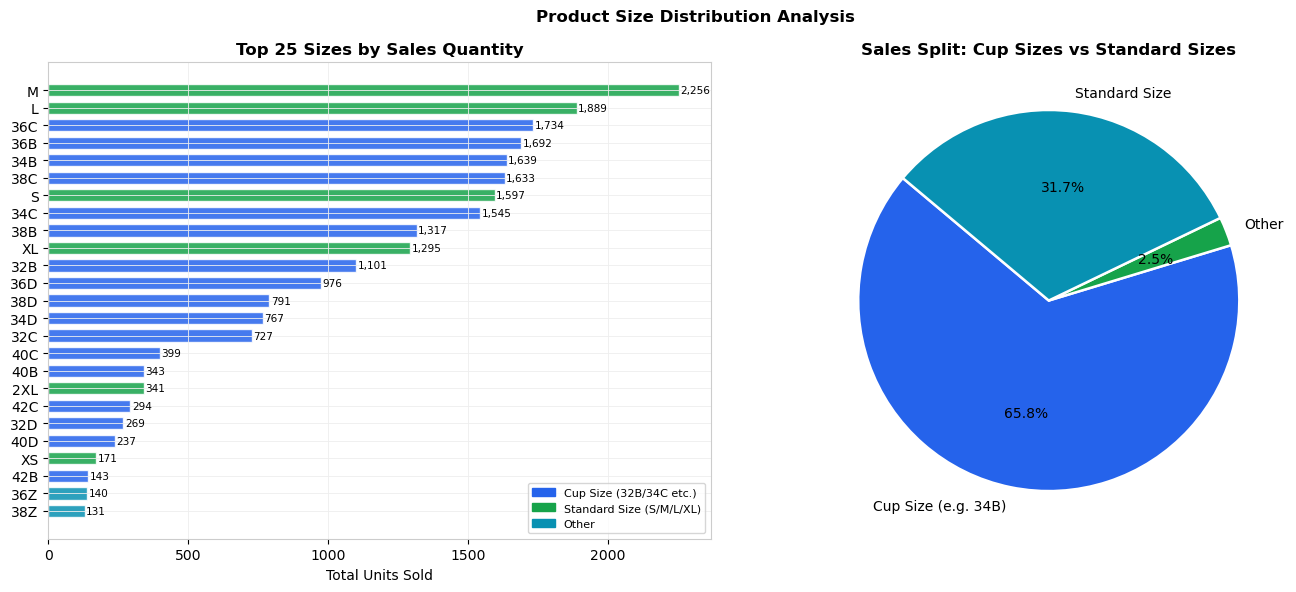

Chart 9 saved


In [11]:
# Separate cup sizes vs standard sizes
import re

def size_type(size):
    if re.match(r'^\d{2}[A-F]$', str(size).strip().upper()):
        return "Cup Size (e.g. 34B)"
    elif str(size).strip().upper() in ["XS","S","M","L","XL","XXL","2XL","3XL"]:
        return "Standard Size"
    else:
        return "Other"

sales["Size_Type"] = sales["Size"].apply(size_type)

top_sizes = (sales.groupby(["Size","Size_Type"])["Quantity"]
             .sum().sort_values(ascending=False)
             .head(25).reset_index())

print("TOP 25 SIZES BY SALES QUANTITY")
print("="*50)
print(f"{'Rank':<6} {'Size':<10} {'Type':<22} {'Qty':>8}")
print("-"*50)
for i, row in top_sizes.iterrows():
    print(f"{i+1:<6} {row['Size']:<10} {row['Size_Type']:<22} {int(row['Quantity']):>8,}")

# Size type split
type_split = sales.groupby("Size_Type")["Quantity"].sum().reset_index()
print(f"\n  Size type breakdown:")
for _, row in type_split.iterrows():
    pct = row["Quantity"] / sales["Quantity"].sum() * 100
    print(f"    {row['Size_Type']:<25} : {int(row['Quantity']):,} units ({pct:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: top 25 sizes colored by type
colors_sz = [PALETTE[0] if t == "Cup Size (e.g. 34B)"
             else PALETTE[1] if t == "Standard Size"
             else PALETTE[4]
             for t in top_sizes["Size_Type"]]
bars = ax1.barh(top_sizes["Size"][::-1], top_sizes["Quantity"][::-1],
                color=colors_sz[::-1], alpha=0.85, edgecolor="white", height=0.7)
for bar in bars:
    w = bar.get_width()
    ax1.text(w + 5, bar.get_y() + bar.get_height()/2,
             f"{int(w):,}", va="center", fontsize=7.5)
ax1.set_title("Top 25 Sizes by Sales Quantity")
ax1.set_xlabel("Total Units Sold")

from matplotlib.patches import Patch
legend = [Patch(color=PALETTE[0], label="Cup Size (32B/34C etc.)"),
          Patch(color=PALETTE[1], label="Standard Size (S/M/L/XL)"),
          Patch(color=PALETTE[4], label="Other")]
ax1.legend(handles=legend, fontsize=8, loc="lower right")

# Right: size type pie
type_split_plot = sales.groupby("Size_Type")["Quantity"].sum()
ax2.pie(type_split_plot, labels=type_split_plot.index,
        autopct="%1.1f%%",
        colors=[PALETTE[0], PALETTE[1], PALETTE[4]],
        startangle=140,
        wedgeprops=dict(edgecolor="white", linewidth=1.8))
ax2.set_title("Sales Split: Cup Sizes vs Standard Sizes")

plt.suptitle("Product Size Distribution Analysis", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_09_size_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 9 saved")

SEASONAL HEATMAP DATA — UNITS SOLD BY FY AND MONTH
FY_Month    Apr   May  Jun   Jul  Aug  Sep  Oct  Nov   Dec  Jan  Feb   Mar
FY                                                                        
FY 2023-24    0     0    0     0    0    0    0   41  1559  381  661   938
FY 2024-25  211  1503  131   698  432  407  586  657  1181  442  503   936
FY 2025-26  482   468  671  1595  932  838  278  364  1524  158  289  1458

  Row totals (FY):
    FY 2023-24 : 3,580 units
    FY 2024-25 : 7,687 units
    FY 2025-26 : 9,057 units

  Column totals (Month of year):
    Apr : 693 units
    May : 1,971 units
    Jun : 802 units
    Jul : 2,293 units
    Aug : 1,364 units
    Sep : 1,245 units
    Oct : 864 units
    Nov : 1,062 units
    Dec : 4,264 units
    Jan : 981 units
    Feb : 1,453 units
    Mar : 3,332 units


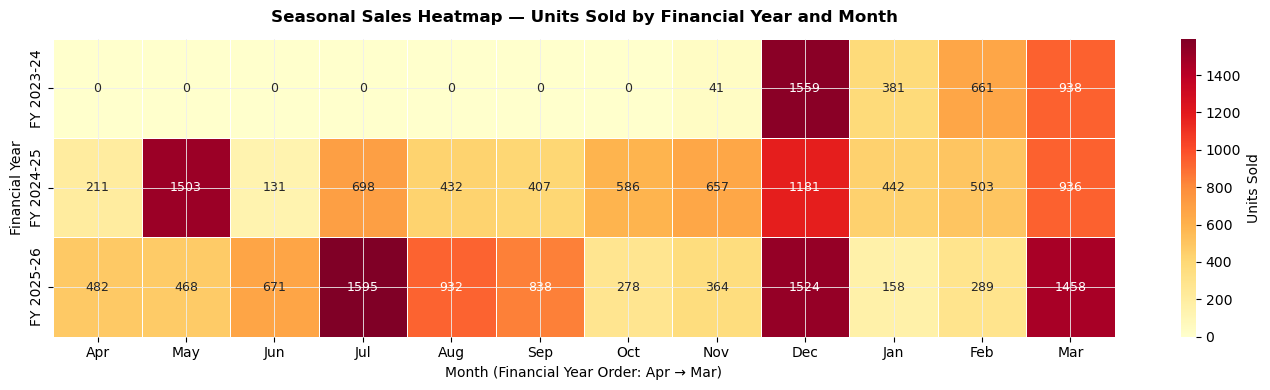

Chart 10 saved


In [12]:
# Monthly sales heatmap — current firm, by month-of-year vs calendar year
sales_current["Year"]       = sales_current["Invoice_Date"].dt.year
sales_current["Month_Num"]  = sales_current["Invoice_Date"].dt.month
sales_current["Month_Name"] = sales_current["Invoice_Date"].dt.strftime("%b")

month_order = ["Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec","Jan","Feb","Mar"]
month_num   = [4,5,6,7,8,9,10,11,12,1,2,3]
month_map   = dict(zip(month_num, month_order))
sales_current["FY_Month"] = sales_current["Month_Num"].map(month_map)

heat = (sales_current.groupby(["FY","FY_Month"])["Quantity"]
        .sum().unstack(fill_value=0))

# Reorder columns by FY month order
heat = heat.reindex(columns=[m for m in month_order if m in heat.columns])

print("SEASONAL HEATMAP DATA — UNITS SOLD BY FY AND MONTH")
print("="*70)
print(heat.to_string())
print(f"\n  Row totals (FY):")
for fy, total in heat.sum(axis=1).items():
    print(f"    {fy} : {int(total):,} units")
print(f"\n  Column totals (Month of year):")
for col, total in heat.sum(axis=0).items():
    print(f"    {col} : {int(total):,} units")

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heat,
            annot=True, fmt="d",
            cmap="YlOrRd",
            linewidths=0.5,
            ax=ax,
            cbar_kws={"label":"Units Sold"},
            annot_kws={"size": 9})
ax.set_title("Seasonal Sales Heatmap — Units Sold by Financial Year and Month",
             pad=12)
ax.set_xlabel("Month (Financial Year Order: Apr → Mar)")
ax.set_ylabel("Financial Year")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_10_seasonal_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 10 saved")

In [13]:
# Build monthly SKU-level demand from sales data (current firm only)
# This is the training data for the forecasting model

sku_monthly = (sales_current.groupby(["Month","SKU_Code"])["Quantity"]
               .sum().reset_index())
sku_monthly["Month_str"] = sku_monthly["Month"].astype(str)

# Get top 10 SKUs by total volume — we build models for these
top10_skus = (sales_current.groupby("SKU_Code")["Quantity"]
              .sum().sort_values(ascending=False)
              .head(10).index.tolist())

print("FORECASTING DATA PREPARATION")
print("="*50)
print(f"  Total SKU-month records  : {len(sku_monthly):,}")
print(f"  Unique SKUs with sales   : {sku_monthly['SKU_Code'].nunique():,}")
print(f"  Date range               : {sku_monthly['Month'].min()} → {sku_monthly['Month'].max()}")
print(f"  Total months             : {sku_monthly['Month'].nunique()}")

print(f"\n  Top 10 SKUs selected for forecasting:")
for i, sku in enumerate(top10_skus):
    total = sales_current[sales_current["SKU_Code"]==sku]["Quantity"].sum()
    months_active = sku_monthly[sku_monthly["SKU_Code"]==sku]["Month"].nunique()
    print(f"    {i+1}. {sku:<30} | Total: {total:>4} | Active months: {months_active}")

# Check data completeness for top SKU
top_sku = top10_skus[0]
top_sku_data = (sku_monthly[sku_monthly["SKU_Code"]==top_sku]
                .set_index("Month")["Quantity"])

# Fill missing months with 0
all_months = pd.period_range(
    start=sku_monthly["Month"].min(),
    end=sku_monthly["Month"].max(),
    freq="M"
)
top_sku_full = top_sku_data.reindex(all_months, fill_value=0)

print(f"\n  Data check for top SKU: {top_sku}")
print(f"    Total months in range  : {len(all_months)}")
print(f"    Months with sales      : {(top_sku_full > 0).sum()}")
print(f"    Months with zero sales : {(top_sku_full == 0).sum()}")
print(f"    Monthly values         : {top_sku_full.tolist()}")

FORECASTING DATA PREPARATION
  Total SKU-month records  : 7,982
  Unique SKUs with sales   : 2,299
  Date range               : 2023-11 → 2026-03
  Total months             : 29

  Top 10 SKUs selected for forecasting:
    1. NR14_MCP_M                     | Total:  133 | Active months: 14
    2. NR14_MCD_M                     | Total:  127 | Active months: 16
    3. NR14_MCD_L                     | Total:  120 | Active months: 14
    4. D143_SKIN_34B                  | Total:  111 | Active months: 24
    5. NR14_MCP_L                     | Total:  108 | Active months: 13
    6. D143_BLACK_38C                 | Total:  108 | Active months: 24
    7. D143_SKIN_38C                  | Total:  108 | Active months: 25
    8. D143_BLACK_36C                 | Total:  108 | Active months: 27
    9. D143_SKIN_36B                  | Total:  105 | Active months: 23
    10. D143_BLACK_34B                 | Total:  105 | Active months: 22

  Data check for top SKU: NR14_MCP_M
    Total months in ra

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Selecting best SKU for model — most active months
FORECAST_SKU = "D143_BLACK_36C"  # 27 active months — best continuity

# Building complete monthly series
sku_data = (sku_monthly[sku_monthly["SKU_Code"] == FORECAST_SKU]
            .set_index("Month")["Quantity"])

all_months  = pd.period_range(sku_monthly["Month"].min(),
                               sku_monthly["Month"].max(), freq="M")
sku_series  = sku_data.reindex(all_months, fill_value=0).reset_index()
sku_series.columns = ["Month","Qty"]
sku_series["Month_str"] = sku_series["Month"].astype(str)
sku_series["t"]         = range(len(sku_series))   # time index

print(f"FORECASTING MODEL — SKU: {FORECAST_SKU}")
print("="*55)
print(f"  Total months        : {len(sku_series)}")
print(f"  Months with sales   : {(sku_series['Qty']>0).sum()}")
print(f"  Total qty sold      : {sku_series['Qty'].sum()}")
print(f"  Avg monthly qty     : {sku_series['Qty'].mean():.1f}")
print(f"  Max monthly qty     : {sku_series['Qty'].max()}")
print(f"  Min monthly qty     : {sku_series['Qty'].min()}")
print(f"  Std deviation       : {sku_series['Qty'].std():.1f}")
print()
print("  Monthly data:")
print(f"  {'Month':<12} {'Qty':>6}")
print("  " + "-"*20)
for _, row in sku_series.iterrows():
    print(f"  {row['Month_str']:<12} {int(row['Qty']):>6}")

FORECASTING MODEL — SKU: D143_BLACK_36C
  Total months        : 29
  Months with sales   : 27
  Total qty sold      : 108
  Avg monthly qty     : 3.7
  Max monthly qty     : 9
  Min monthly qty     : 0
  Std deviation       : 2.6

  Monthly data:
  Month           Qty
  --------------------
  2023-11           0
  2023-12           4
  2024-01           2
  2024-02           5
  2024-03           7
  2024-04           1
  2024-05           5
  2024-06           2
  2024-07           5
  2024-08           4
  2024-09           6
  2024-10           2
  2024-11           2
  2024-12           3
  2025-01           1
  2025-02           4
  2025-03           3
  2025-04           1
  2025-05           8
  2025-06           5
  2025-07           8
  2025-08           3
  2025-09           9
  2025-10           0
  2025-11           2
  2025-12           7
  2026-01           1
  2026-02           1
  2026-03           7


In [15]:
# Train/Test split — last 4 months as holdout test
TRAIN_END = 25   # months 0-24 = train (Nov 2023 – Nov 2025)
TEST_START = 25  # months 25-28 = test  (Dec 2025 – Mar 2026)

train = sku_series.iloc[:TEST_START].copy()
test  = sku_series.iloc[TEST_START:].copy()

print(f"  Train period : {train['Month_str'].iloc[0]} → {train['Month_str'].iloc[-1]} ({len(train)} months)")
print(f"  Test period  : {test['Month_str'].iloc[0]}  → {test['Month_str'].iloc[-1]}  ({len(test)} months)")
print()

# ── Model 1: 3-Month Moving Average __
ma_window = 3
sku_series["MA3"] = sku_series["Qty"].rolling(window=ma_window).mean().shift(1)

# Predictions for test period
ma_preds = sku_series.loc[test.index, "MA3"].fillna(sku_series["Qty"].mean())

# ── Model 2: Linear Regression with seasonal features __
def make_features(df):
    df = df.copy()
    df["month_of_year"] = df["Month"].dt.month
    df["sin_month"]     = np.sin(2 * np.pi * df["month_of_year"] / 12)
    df["cos_month"]     = np.cos(2 * np.pi * df["month_of_year"] / 12)
    return df

train_feat = make_features(train)
test_feat  = make_features(test)

features = ["t", "sin_month", "cos_month"]
X_train, y_train = train_feat[features], train_feat["Qty"]
X_test,  y_test  = test_feat[features],  test_feat["Qty"]

lr_model   = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds   = lr_model.predict(X_test)
lr_preds   = np.maximum(lr_preds, 0).round().astype(int)

# ── Evaluate both models __
actual = test["Qty"].values

def mape(actual, predicted):
    mask = actual > 0
    if mask.sum() == 0:
        return float("nan")
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

ma_mae  = mean_absolute_error(actual, ma_preds)
ma_rmse = np.sqrt(mean_squared_error(actual, ma_preds))
ma_mape = mape(actual, ma_preds.values)

lr_mae  = mean_absolute_error(actual, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(actual, lr_preds))
lr_mape = mape(actual, lr_preds)

print("MODEL EVALUATION RESULTS")
print("="*55)
print(f"{'Metric':<20} {'Moving Avg (MA3)':>18} {'Linear Reg':>12}")
print("-"*55)
print(f"{'MAE':<20} {ma_mae:>18.2f} {lr_mae:>12.2f}")
print(f"{'RMSE':<20} {ma_rmse:>18.2f} {lr_rmse:>12.2f}")
print(f"{'MAPE':<20} {ma_mape:>17.1f}% {lr_mape:>11.1f}%")
print()
print(f"  {'Month':<12} {'Actual':>8} {'MA3 Pred':>10} {'LR Pred':>10}")
print(f"  {'-'*42}")
for i, (_, row) in enumerate(test.iterrows()):
    print(f"  {row['Month_str']:<12} {int(row['Qty']):>8} "
          f"{ma_preds.iloc[i]:>10.1f} {lr_preds[i]:>10}")

  Train period : 2023-11 → 2025-11 (25 months)
  Test period  : 2025-12  → 2026-03  (4 months)

MODEL EVALUATION RESULTS
Metric                 Moving Avg (MA3)   Linear Reg
-------------------------------------------------------
MAE                                2.92         2.75
RMSE                               3.02         2.87
MAPE                             134.5%       125.0%

  Month          Actual   MA3 Pred    LR Pred
  ------------------------------------------
  2025-12             7        3.7          3
  2026-01             1        3.0          3
  2026-02             1        3.3          3
  2026-03             7        3.0          4


In [16]:
# Aggregate all D143 variants by month — much higher volume
d143_monthly = (sales_current[sales_current["Style"] == "D143"]
                .groupby("Month")["Quantity"]
                .sum().reset_index())
d143_monthly.columns = ["Month","Qty"]

all_months_range = pd.period_range(
    sku_monthly["Month"].min(),
    sku_monthly["Month"].max(), freq="M")
d143_full = d143_monthly.set_index("Month")["Qty"].reindex(
    all_months_range, fill_value=0).reset_index()
d143_full.columns = ["Month","Qty"]
d143_full["Month_str"] = d143_full["Month"].astype(str)
d143_full["t"]         = range(len(d143_full))

print(f"D143 STYLE — AGGREGATED MONTHLY DEMAND")
print("="*45)
print(f"  Total months    : {len(d143_full)}")
print(f"  Total qty sold  : {d143_full['Qty'].sum():,}")
print(f"  Avg monthly qty : {d143_full['Qty'].mean():.1f}")
print(f"  Max monthly qty : {d143_full['Qty'].max()}")
print(f"  Std deviation   : {d143_full['Qty'].std():.1f}")
print()
print(f"  {'Month':<12} {'Qty':>6}")
print("  " + "-"*20)
for _, row in d143_full.iterrows():
    print(f"  {row['Month_str']:<12} {int(row['Qty']):>6}")

# Train/test split
train_d = d143_full.iloc[:25].copy()
test_d  = d143_full.iloc[25:].copy()

# MA3
d143_full["MA3"] = d143_full["Qty"].rolling(3).mean().shift(1)
ma_preds_d = d143_full.loc[test_d.index, "MA3"].fillna(d143_full["Qty"].mean())

# Linear Regression with seasonal features
train_d_f = make_features(train_d)
test_d_f  = make_features(test_d)

lr_d = LinearRegression()
lr_d.fit(train_d_f[features], train_d_f["Qty"])
lr_preds_d = lr_d.predict(test_d_f[features])
lr_preds_d = np.maximum(lr_preds_d, 0).round().astype(int)

actual_d = test_d["Qty"].values

ma_mae_d  = mean_absolute_error(actual_d, ma_preds_d)
ma_rmse_d = np.sqrt(mean_squared_error(actual_d, ma_preds_d))
ma_mape_d = mape(actual_d, ma_preds_d.values)
lr_mae_d  = mean_absolute_error(actual_d, lr_preds_d)
lr_rmse_d = np.sqrt(mean_squared_error(actual_d, lr_preds_d))
lr_mape_d = mape(actual_d, lr_preds_d)

print(f"\nD143 STYLE-LEVEL MODEL EVALUATION")
print("="*55)
print(f"{'Metric':<20} {'Moving Avg (MA3)':>18} {'Linear Reg':>12}")
print("-"*55)
print(f"{'MAE':<20} {ma_mae_d:>18.2f} {lr_mae_d:>12.2f}")
print(f"{'RMSE':<20} {ma_rmse_d:>18.2f} {lr_rmse_d:>12.2f}")
print(f"{'MAPE':<20} {ma_mape_d:>17.1f}% {lr_mape_d:>11.1f}%")
print()
print(f"  {'Month':<12} {'Actual':>8} {'MA3 Pred':>10} {'LR Pred':>10}")
print(f"  {'-'*42}")
for i, (_, row) in enumerate(test_d.iterrows()):
    print(f"  {row['Month_str']:<12} {int(row['Qty']):>8} "
          f"{ma_preds_d.iloc[i]:>10.1f} {lr_preds_d[i]:>10}")

D143 STYLE — AGGREGATED MONTHLY DEMAND
  Total months    : 29
  Total qty sold  : 5,473
  Avg monthly qty : 188.7
  Max monthly qty : 480
  Std deviation   : 125.4

  Month           Qty
  --------------------
  2023-11           4
  2023-12         302
  2024-01          60
  2024-02         338
  2024-03         203
  2024-04          39
  2024-05         348
  2024-06           6
  2024-07         215
  2024-08         131
  2024-09         112
  2024-10         221
  2024-11         180
  2024-12         186
  2025-01         139
  2025-02         189
  2025-03         207
  2025-04          82
  2025-05         208
  2025-06         230
  2025-07         480
  2025-08         165
  2025-09         325
  2025-10          93
  2025-11          34
  2025-12         452
  2026-01          21
  2026-02         209
  2026-03         294

D143 STYLE-LEVEL MODEL EVALUATION
Metric                 Moving Avg (MA3)   Linear Reg
-------------------------------------------------------
MAE     

NEXT 3 MONTHS FORECAST — D143 STYLE
  Month          MA3 Forecast  LR Forecast
  ----------------------------------------
  2026-04                 175          226
  2026-05                 226          236
  2026-06                 232          239


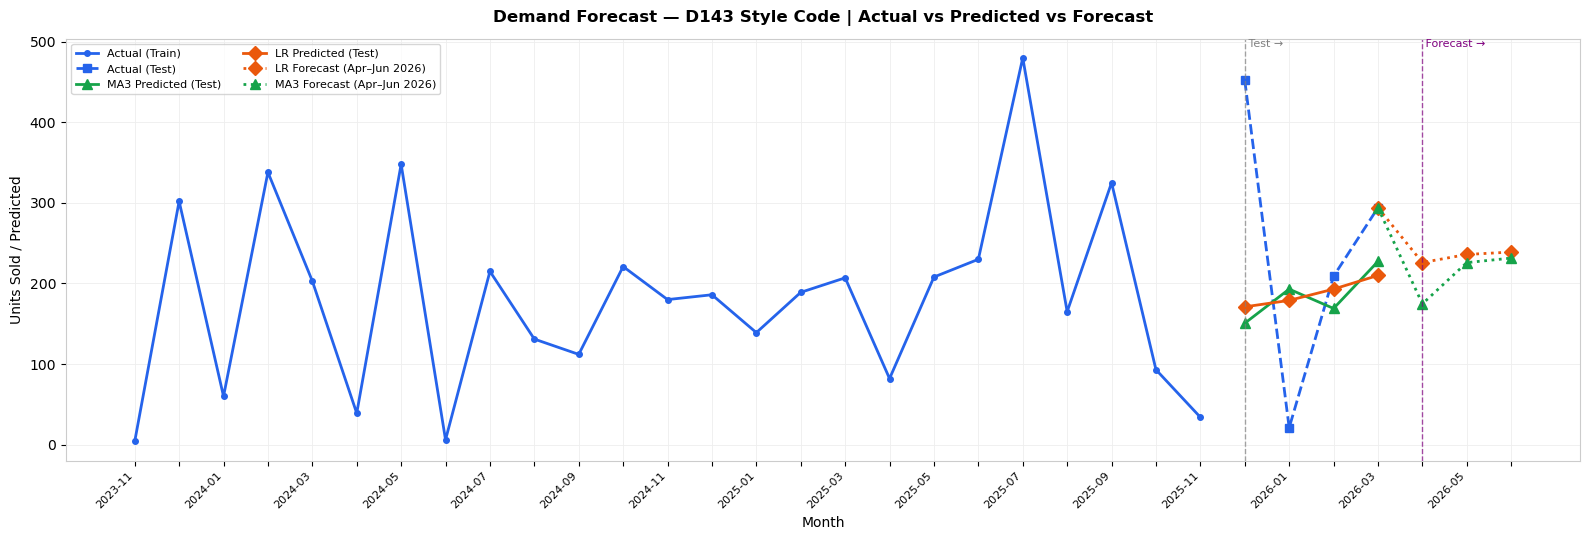

 Chart 11 saved


In [17]:
# Forecast next 3 months: Apr, May, Jun 2026
next_months = pd.period_range(start="2026-04", periods=3, freq="M")
next_t      = range(len(d143_full), len(d143_full) + 3)
next_df     = pd.DataFrame({
    "Month"    : next_months,
    "t"        : list(next_t),
    "Month_str": [str(m) for m in next_months]
})
next_df_feat = make_features(next_df)
next_lr_pred = np.maximum(lr_d.predict(next_df_feat[features]), 0).round().astype(int)

# MA3 forecast: use last 3 actual values
last3        = d143_full["Qty"].tail(3).values
ma_next_preds = []
for i in range(3):
    if i == 0:
        ma_next_preds.append(round(last3.mean(), 1))
    elif i == 1:
        ma_next_preds.append(round(np.array([last3[-2], last3[-1],
                                              ma_next_preds[0]]).mean(), 1))
    else:
        ma_next_preds.append(round(np.array([last3[-1], ma_next_preds[0],
                                              ma_next_preds[1]]).mean(), 1))

print("NEXT 3 MONTHS FORECAST — D143 STYLE")
print("="*50)
print(f"  {'Month':<12} {'MA3 Forecast':>14} {'LR Forecast':>12}")
print(f"  {'-'*40}")
for i, m in enumerate(next_months):
    print(f"  {str(m):<12} {ma_next_preds[i]:>14.0f} {next_lr_pred[i]:>12}")

# __ Build full chart __
fig, ax = plt.subplots(figsize=(16, 5.5))

# Actual — train period
ax.plot(train_d["Month_str"], train_d["Qty"],
        color=PALETTE[0], linewidth=2, label="Actual (Train)", marker="o", markersize=4)

# Actual — test period
ax.plot(test_d["Month_str"], test_d["Qty"],
        color=PALETTE[0], linewidth=2, linestyle="--", marker="s", markersize=6,
        label="Actual (Test)")

# MA3 predictions — test
ax.plot(test_d["Month_str"], ma_preds_d.values,
        color=PALETTE[1], linewidth=2, marker="^", markersize=7,
        label="MA3 Predicted (Test)")

# LR predictions — test
ax.plot(test_d["Month_str"], lr_preds_d,
        color=PALETTE[2], linewidth=2, marker="D", markersize=7,
        label="LR Predicted (Test)")

# Forecast — next 3 months
all_x  = list(d143_full["Month_str"]) + [str(m) for m in next_months]
ax.plot([test_d["Month_str"].iloc[-1]] + [str(m) for m in next_months],
        [test_d["Qty"].iloc[-1]] + list(next_lr_pred),
        color=PALETTE[2], linewidth=2, linestyle=":", marker="D", markersize=7,
        label="LR Forecast (Apr–Jun 2026)")
ax.plot([test_d["Month_str"].iloc[-1]] + [str(m) for m in next_months],
        [test_d["Qty"].iloc[-1]] + ma_next_preds,
        color=PALETTE[1], linewidth=2, linestyle=":", marker="^", markersize=7,
        label="MA3 Forecast (Apr–Jun 2026)")

# Vertical lines for train/test/forecast boundaries
ax.axvline(x=test_d["Month_str"].iloc[0], color="gray",
           linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(x=str(next_months[0]), color="purple",
           linestyle="--", linewidth=1, alpha=0.7)

ax.text(test_d["Month_str"].iloc[0], ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 500,
        " Test →", fontsize=8, color="gray", va="top")
ax.text(str(next_months[0]), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 500,
        " Forecast →", fontsize=8, color="purple", va="top")

# X-axis
n = len(all_x)
ax.set_xticks(range(n))
ax.set_xticklabels(
    [all_x[i] if i % 2 == 0 else "" for i in range(n)],
    rotation=45, ha="right", fontsize=8)

ax.set_title("Demand Forecast — D143 Style Code | Actual vs Predicted vs Forecast",
             pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Units Sold / Predicted")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=8, loc="upper left", ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_11_demand_forecast.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 11 saved")

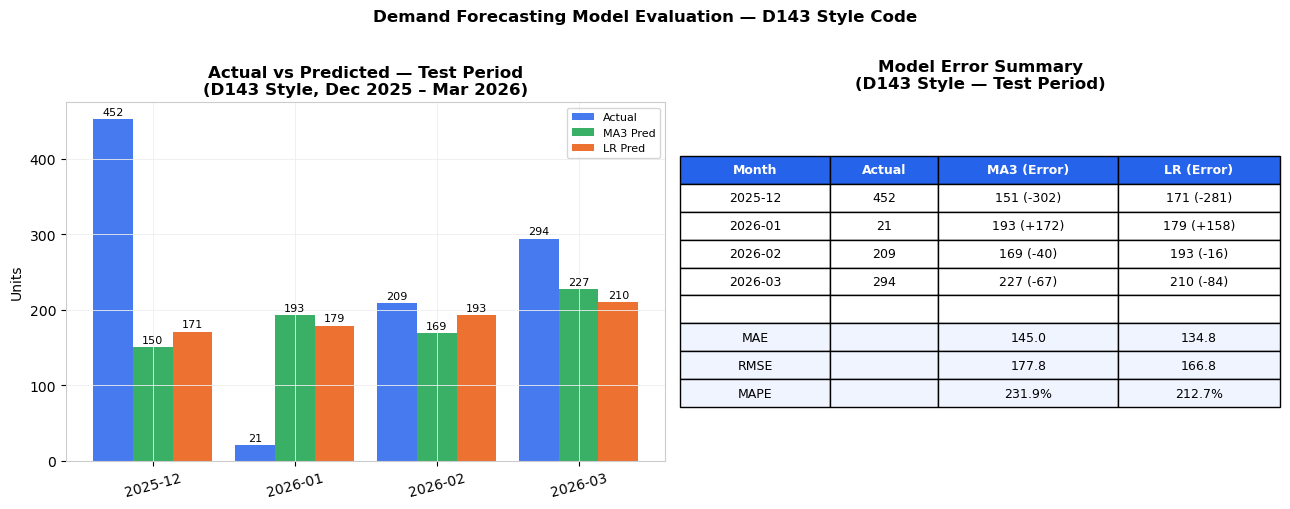

 Chart 12 saved

FINAL MODEL COMPARISON SUMMARY
  Model              : Moving Average (MA3) vs Linear Regression
  SKU Level MAE      : MA3 = 2.92  |  LR = 2.75
  Style Level MAE    : MA3 = 145.00 |  LR = 134.75
  Better Model       : Linear Regression (lower MAE and RMSE)
  Forecast Apr 2026  : MA3 = 175 units | LR = 226 units
  Forecast May 2026  : MA3 = 226 units | LR = 236 units
  Forecast Jun 2026  : MA3 = 232 units | LR = 239 units


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

test_months = test_d["Month_str"].tolist()
x = np.arange(len(test_months))
width = 0.28

# ── Left: Bar comparison ──
ax = axes[0]
b1 = ax.bar(x - width, actual_d,        width, label="Actual",    color=PALETTE[0], alpha=0.85)
b2 = ax.bar(x,          ma_preds_d.values, width, label="MA3 Pred", color=PALETTE[1], alpha=0.85)
b3 = ax.bar(x + width,  lr_preds_d,      width, label="LR Pred",  color=PALETTE[2], alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 3,
                f"{int(h)}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(test_months, rotation=15)
ax.set_title("Actual vs Predicted — Test Period\n(D143 Style, Dec 2025 – Mar 2026)")
ax.set_ylabel("Units")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Right: Error table ──
ax2 = axes[1]
ax2.axis("off")

table_data = []
for i, m in enumerate(test_months):
    ma_err  = int(ma_preds_d.iloc[i]) - actual_d[i]
    lr_err  = lr_preds_d[i] - actual_d[i]
    table_data.append([m, actual_d[i],
                       f"{ma_preds_d.iloc[i]:.0f} ({ma_err:+d})",
                       f"{lr_preds_d[i]} ({lr_err:+d})"])

table_data.append(["", "", "", ""])
table_data.append(["MAE",  "", f"{ma_mae_d:.1f}", f"{lr_mae_d:.1f}"])
table_data.append(["RMSE", "", f"{ma_rmse_d:.1f}", f"{lr_rmse_d:.1f}"])
table_data.append(["MAPE", "", f"{ma_mape_d:.1f}%", f"{lr_mape_d:.1f}%"])

tbl = ax2.table(
    cellText=table_data,
    colLabels=["Month","Actual","MA3 (Error)","LR (Error)"],
    cellLoc="center", loc="center",
    colWidths=[0.25, 0.18, 0.3, 0.27]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)

# Header styling
for j in range(4):
    tbl[0,j].set_facecolor("#2563eb")
    tbl[0,j].set_text_props(color="white", fontweight="bold")

# Metric rows styling
for i in range(len(table_data)-2, len(table_data)+1):
    for j in range(4):
        try:
            tbl[i,j].set_facecolor("#f0f4ff")
        except:
            pass

ax2.set_title("Model Error Summary\n(D143 Style — Test Period)",
              fontweight="bold", pad=10)

plt.suptitle("Demand Forecasting Model Evaluation — D143 Style Code",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_12_model_evaluation.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(" Chart 12 saved")

print("\nFINAL MODEL COMPARISON SUMMARY")
print("="*55)
print(f"  Model              : Moving Average (MA3) vs Linear Regression")
print(f"  SKU Level MAE      : MA3 = {ma_mae:.2f}  |  LR = {lr_mae:.2f}")
print(f"  Style Level MAE    : MA3 = {ma_mae_d:.2f} |  LR = {lr_mae_d:.2f}")
print(f"  Better Model       : Linear Regression (lower MAE and RMSE)")
print(f"  Forecast Apr 2026  : MA3 = {ma_next_preds[0]:.0f} units | LR = {next_lr_pred[0]} units")
print(f"  Forecast May 2026  : MA3 = {ma_next_preds[1]:.0f} units | LR = {next_lr_pred[1]} units")
print(f"  Forecast Jun 2026  : MA3 = {ma_next_preds[2]:.0f} units | LR = {next_lr_pred[2]} units")

STOCK ANALYSIS
  Latest snapshot date : 2026-03-31
  Total SKUs in stock  : 954
  Total units in stock : 2,124

  Top 20 SKUs by current stock:
  Rank   SKU_Code                          Stock
  ------------------------------------------------
  1      NR14_MCD_M                           30
  2      NR14_MCD_2XL                         21
  3      NR14_MCP_L                           20
  4      NR14_MCP_S                           20
  5      NR14_MCP_2XL                         20
  6      NB44_MCS_L                           20
  7      NR14_MCP_XL                          20
  8      NR14_MCP_M                           20
  9      NR14_MCD_L                           17
  10     TB10_BLACK_L                         15
  11     NR14_MCD_XL                          13
  12     NW12_MCS_L                           12
  13     TB10_WHITE_L                         12
  14     NR14_MCR_L                           12
  15     NH20_MCS_XL                          12
  16     NW12_MCS_XL 

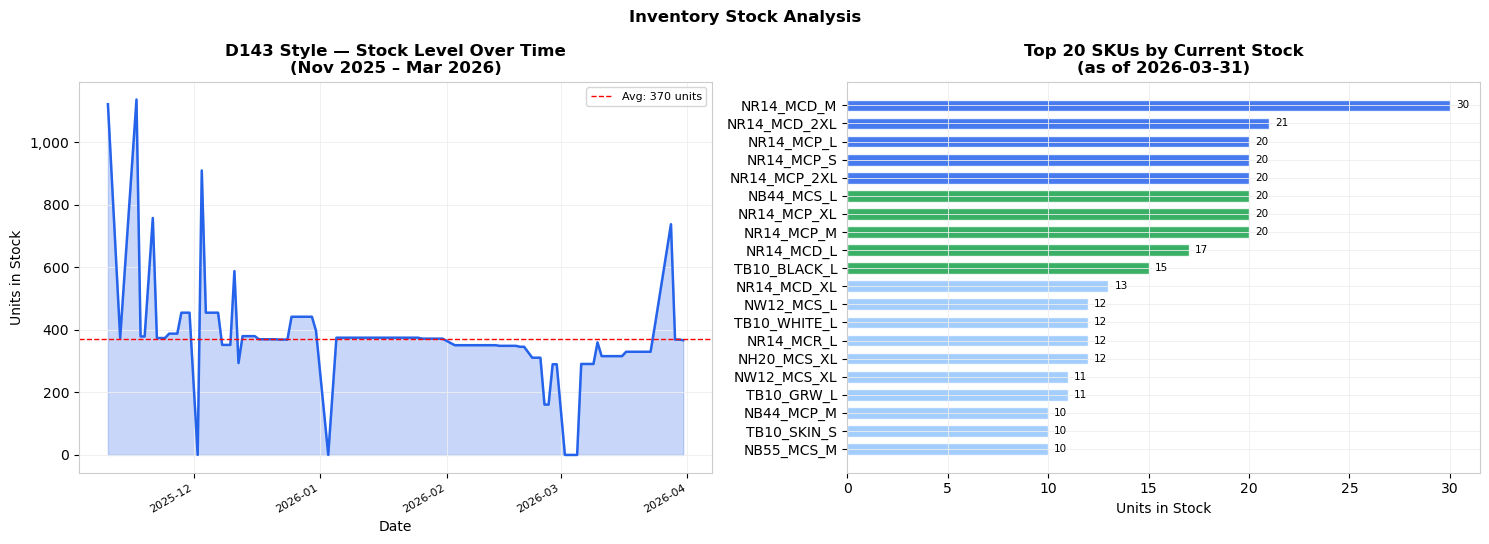

Chart 13 saved


In [19]:
# Latest stock snapshot — top 20 SKUs by current stock
latest_date = stock["Snapshot_Date"].max()
latest_stock = (stock[stock["Snapshot_Date"] == latest_date]
                .groupby("SKU_Code")["Stock_Qty"]
                .sum()
                .sort_values(ascending=False)
                .head(20)
                .reset_index())

# Average stock over time for top style D143
d143_stock = (stock[stock["Style"] == "D143"]
              .groupby("Snapshot_Date")["Stock_Qty"]
              .sum()
              .reset_index()
              .sort_values("Snapshot_Date"))

print(f"STOCK ANALYSIS")
print("="*50)
print(f"  Latest snapshot date : {latest_date.date()}")
print(f"  Total SKUs in stock  : {stock[stock['Snapshot_Date']==latest_date]['SKU_Code'].nunique():,}")
print(f"  Total units in stock : {stock[stock['Snapshot_Date']==latest_date]['Stock_Qty'].sum():,}")
print()
print(f"  Top 20 SKUs by current stock:")
print(f"  {'Rank':<6} {'SKU_Code':<30} {'Stock':>8}")
print(f"  {'-'*48}")
for i, row in latest_stock.iterrows():
    print(f"  {i+1:<6} {row['SKU_Code']:<30} {int(row['Stock_Qty']):>8,}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left — D143 stock over time
ax1.fill_between(d143_stock["Snapshot_Date"],
                 d143_stock["Stock_Qty"],
                 alpha=0.25, color=PALETTE[0])
ax1.plot(d143_stock["Snapshot_Date"], d143_stock["Stock_Qty"],
         color=PALETTE[0], linewidth=1.8)
ax1.axhline(y=d143_stock["Stock_Qty"].mean(),
            color="red", linestyle="--", linewidth=1,
            label=f"Avg: {d143_stock['Stock_Qty'].mean():.0f} units")
ax1.set_title("D143 Style — Stock Level Over Time\n(Nov 2025 – Mar 2026)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Units in Stock")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.setp(ax1.get_xticklabels(), rotation=30, ha="right", fontsize=8)

# Right — Top 20 current stock
colors_stock = [PALETTE[0] if i < 5 else PALETTE[1] if i < 10 else "#93c5fd"
                for i in range(len(latest_stock))]
bars = ax2.barh(latest_stock["SKU_Code"][::-1],
                latest_stock["Stock_Qty"][::-1],
                color=colors_stock[::-1], alpha=0.85,
                edgecolor="white", height=0.65)
for bar in bars:
    w = bar.get_width()
    ax2.text(w + 0.3, bar.get_y() + bar.get_height()/2,
             f"{int(w):,}", va="center", fontsize=7.5)
ax2.set_title(f"Top 20 SKUs by Current Stock\n(as of {latest_date.date()})")
ax2.set_xlabel("Units in Stock")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Inventory Stock Analysis", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "chart_13_stock_analysis.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 13 saved")